In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [46]:
# Reading the file

df = pd.read_csv("Full_Titanic.csv")
df = df.drop(columns = 'Unnamed: 0')
print(df.shape[0])
df.head(1)

1309


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Group,family_size,family_type,surname,Title_Grouped,ticket_type
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,Adults,2,Double,Braund,Mr,Prefix


In [47]:
df[['Age','Cabin','Embarked','Fare']].isnull().sum()

Age          263
Cabin       1014
Embarked       2
Fare           1
dtype: int64

## Knowing About the Data

**Columns in the Dataset:-**
- **Survival:-** Whether a passenger survived or not(0/1)
- **Pclass:-** The Socio-Economic Class
            - Upper: 1
            - Middle: 2
            - Lower: 3
- **Sex:-** Gender of the passenger (Male or Female)
- **Age:-** Age in Years
- **SibSp:-** Number of Siblings / Number of Spouses aboard the Titanic.
- **Parch:-** Number of Parents / Children aboard the Titanic.
- **Ticket:-** Ticket number
- **Fare:-** Passenger Fare
- **Cabin:-** Cabin Number
- **Embarked:-** Port of Embarkation
                - C: Cherbourg
                - Q: Queenstown
                - S: Southamptom
- **Age_Group:-** 
                  - i) 0-2   --> Infants
                  -ii) 3-12  --> Children
                 -iii) 13-19 --> Teens
                 - iv) 20-30 --> Adults
                 -  v) 31-60 --> Elder Adults
                 - vi) 61+   --> Senior Citizens
- **Family_Size:-** Total members of a family on board.
- **Family_Type:-** 
                    - i) 1   --> Alone
                   - ii) 2   --> Double 
                  - iii) 3-5 --> Small 
                   - iv) > 5 --> Large 
- **Surname:-**
- **Title:-** Mr,Ms,Miss,..etc
- **Ticket_type:-**

Total Rows    : 1309
Total Columns : 18
Numerical Columns   :
  ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'family_size']
------------------------------------------------------------
Categorical Columns :
  ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked', 'Age_Group', 'family_type', 'surname', 'Title_Grouped', 'ticket_type']
------------------------------------------------------------
Null Value Counts (>1):
Survived      418
Age           263
Cabin        1014
Embarked        2
Age_Group     263
dtype: int64
------------------------------------------------------------
Null Percentages  (>1%):
Survived     31.932773
Age          20.091673
Cabin        77.463713
Age_Group    20.091673
dtype: float64
------------------------------------------------------------
Columns with > 5% Nulls : ['Survived', 'Age', 'Cabin', 'Age_Group']
------------------------------------------------------------
Columns with ≤ 5% Nulls : ['Fare', 'Embarked']
-----------------------------

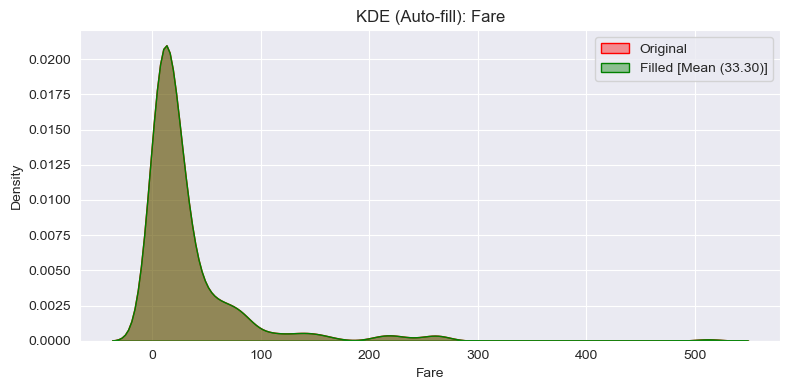

  ✅ 'Fare' filled with Mean (33.30)
------------------------------------------------------------


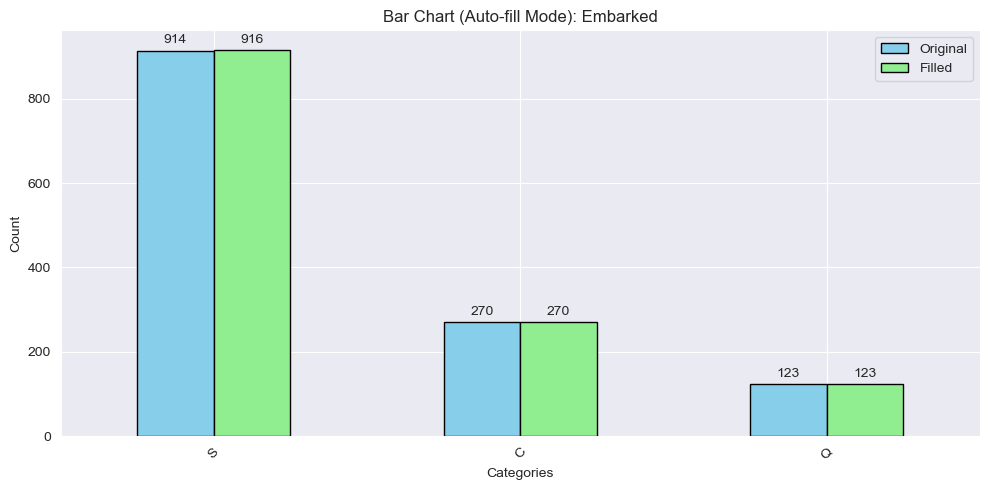

  ✅ 'Embarked' filled with Mode = 'S'
------------------------------------------------------------

EVALUATING COLUMNS WITH > 5% NULL DATA  (user input required)

  COLUMN : Survived


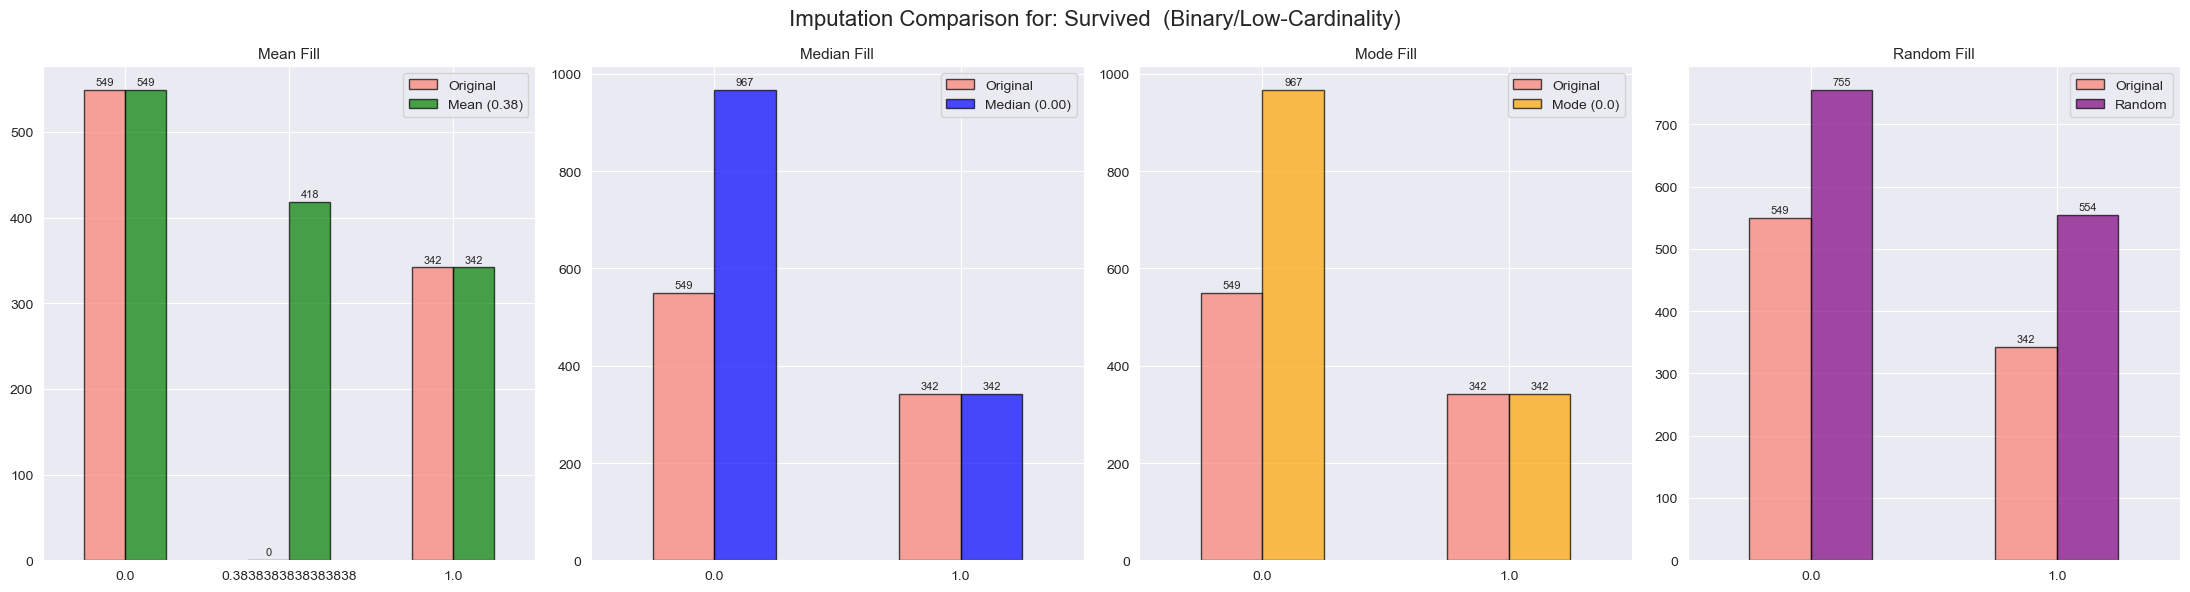


'Survived' is binary/low-cardinality — std dev not shown. Recommend: mode or random.

Fill 'Survived' with which strategy? (mean / median / mode / random) : random
  ✅ 'Survived' filled.
------------------------------------------------------------

  COLUMN : Age


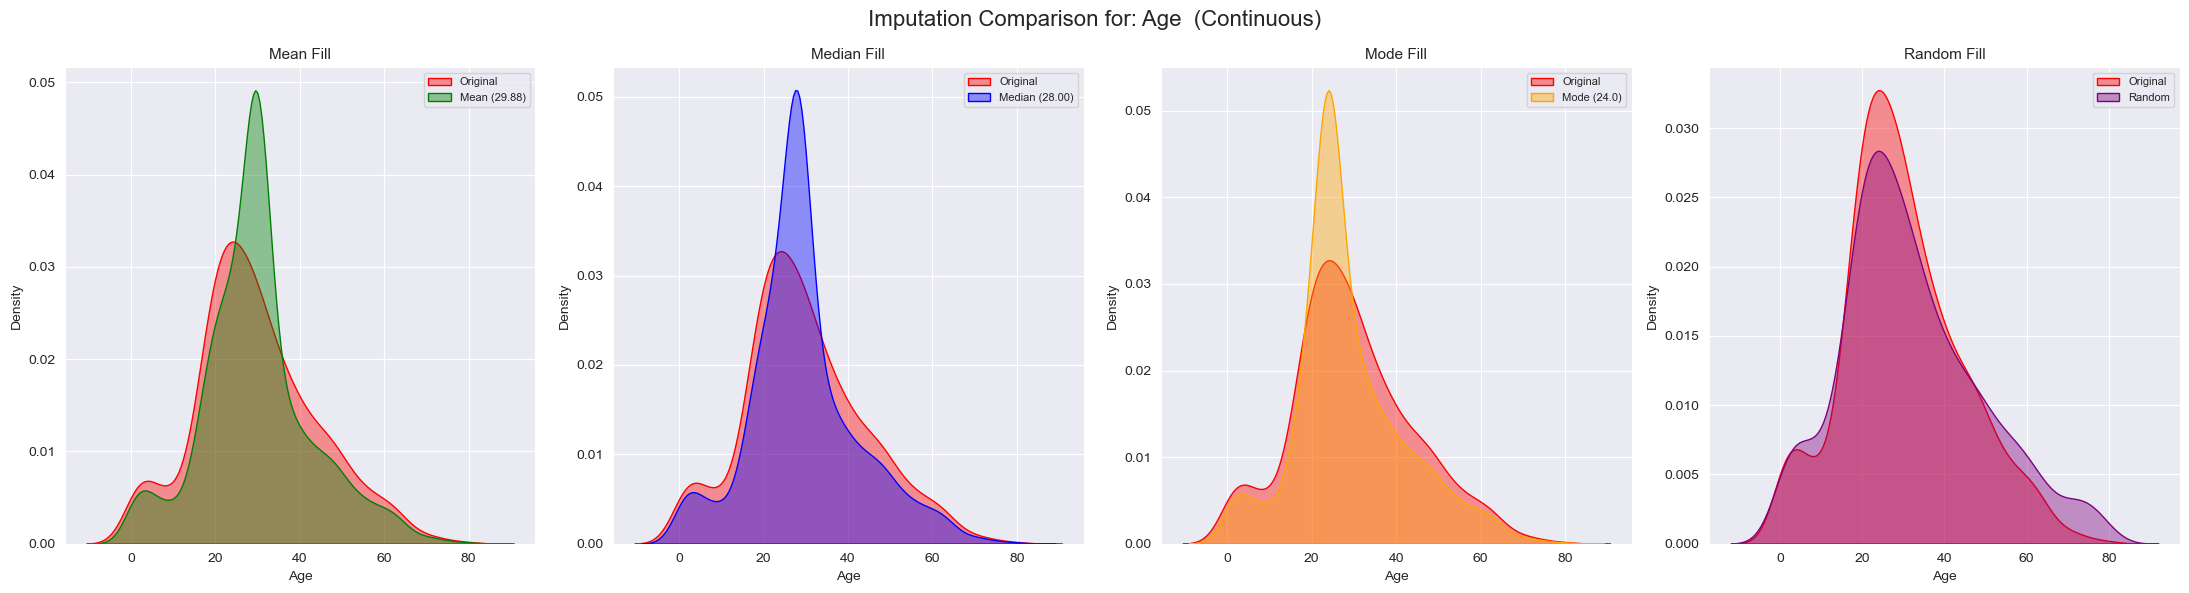


Std Dev Comparison for 'Age'  (closer to Original = better):
  Original : 14.4135
  Mean     : 12.8832
  Median   : 12.9052
  Mode     : 13.0971
  Random   : 16.9685

Fill 'Age' with which strategy? (mean / median / mode / random) : random
  ✅ 'Age' filled.
------------------------------------------------------------

  COLUMN : Cabin


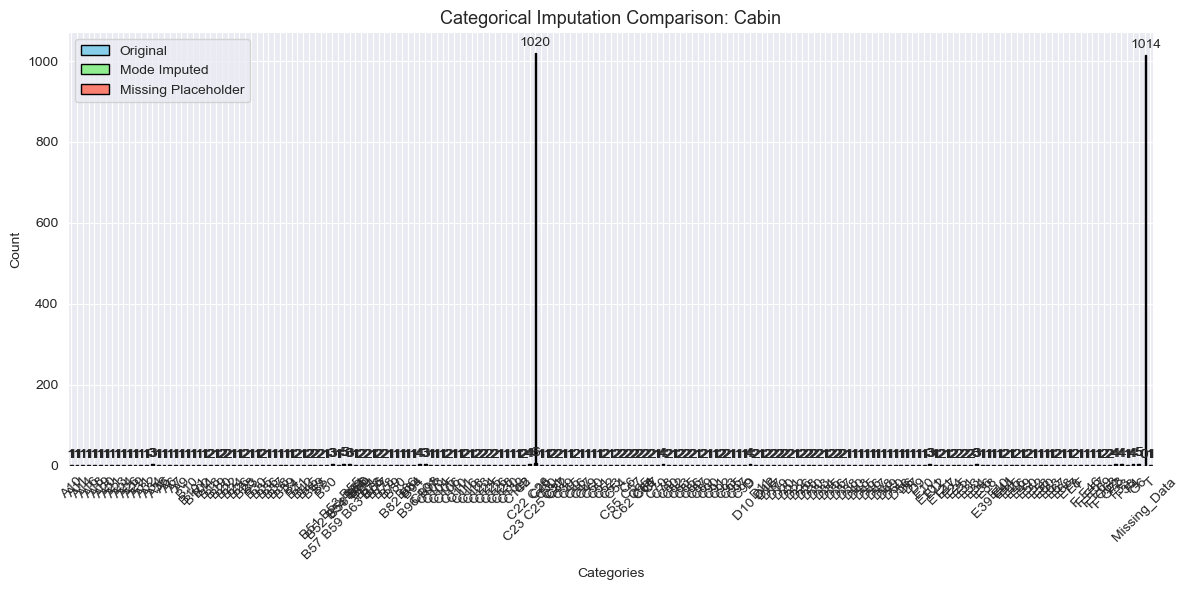


Fill 'Cabin' with which strategy? (mode / missing) : mode
  ✅ 'Cabin' filled with Mode = 'C23 C25 C27'
------------------------------------------------------------

  COLUMN : Age_Group


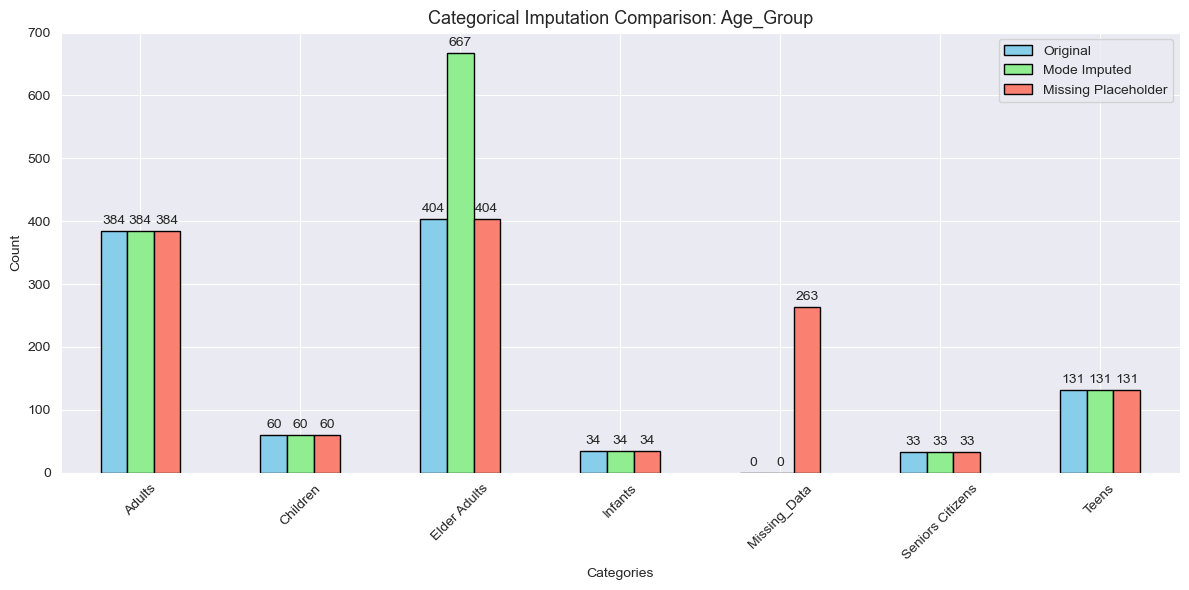


Fill 'Age_Group' with which strategy? (mode / missing) : mode
  ✅ 'Age_Group' filled with Mode = 'Elder Adults'
------------------------------------------------------------

NULL CHECK AFTER FILLING ALL COLUMNS:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin            0
Embarked         0
Age_Group        0
family_size      0
family_type      0
surname          0
Title_Grouped    0
ticket_type      0

FINAL DISTRIBUTION COMPARISON  (Original vs Cleaned)


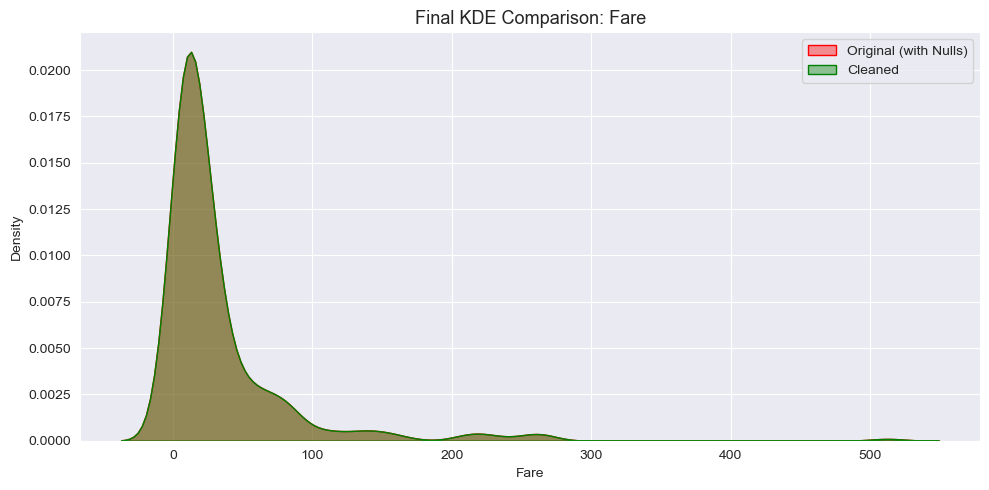

  'Fare'
    Original Mean : 33.2955  |  Cleaned Mean : 33.2955
    Original Std  : 51.7587  |  Cleaned Std  : 51.7389
------------------------------------------------------------


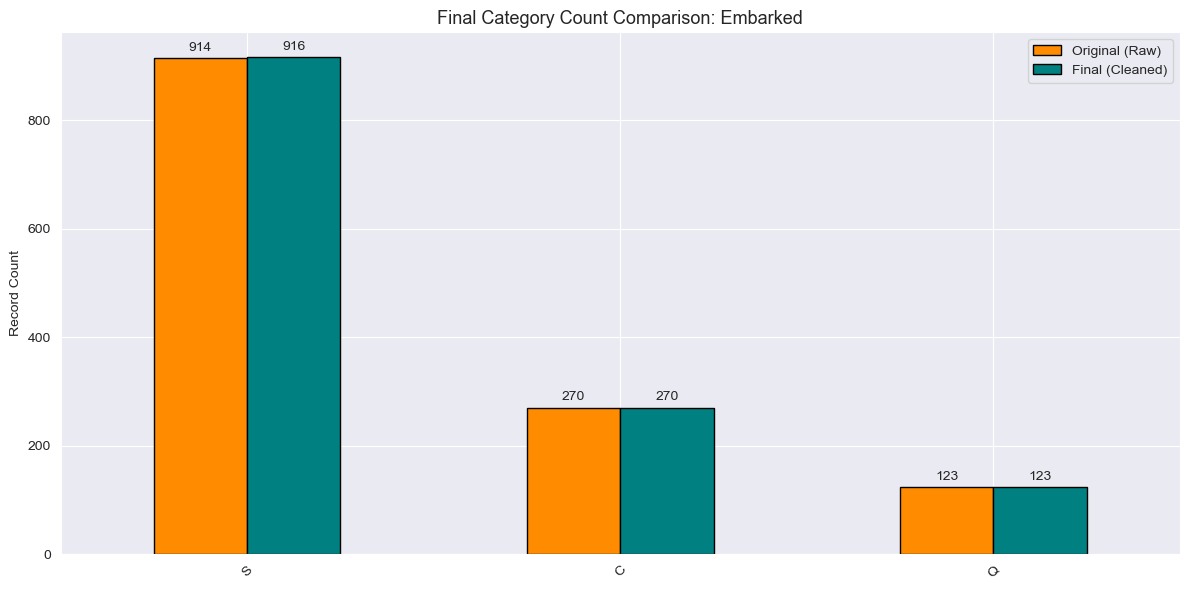

------------------------------------------------------------


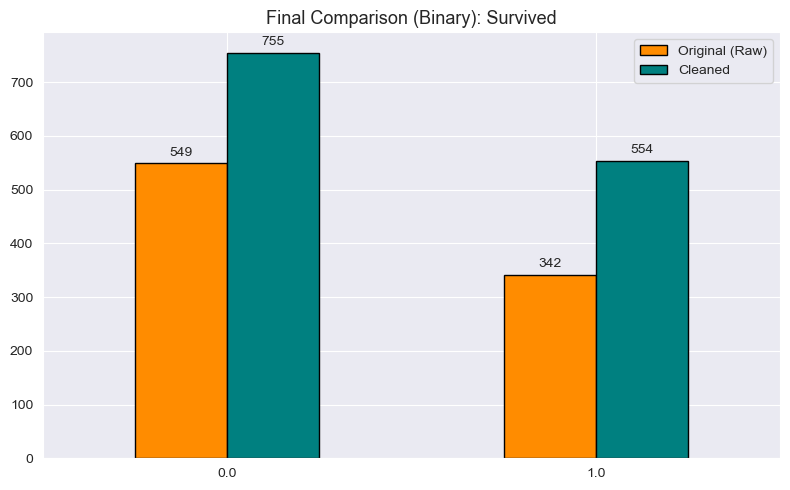

  'Survived'
    Original Mean : 0.3838  |  Cleaned Mean : 0.4232
    Original Std  : 0.4866  |  Cleaned Std  : 0.4943
------------------------------------------------------------


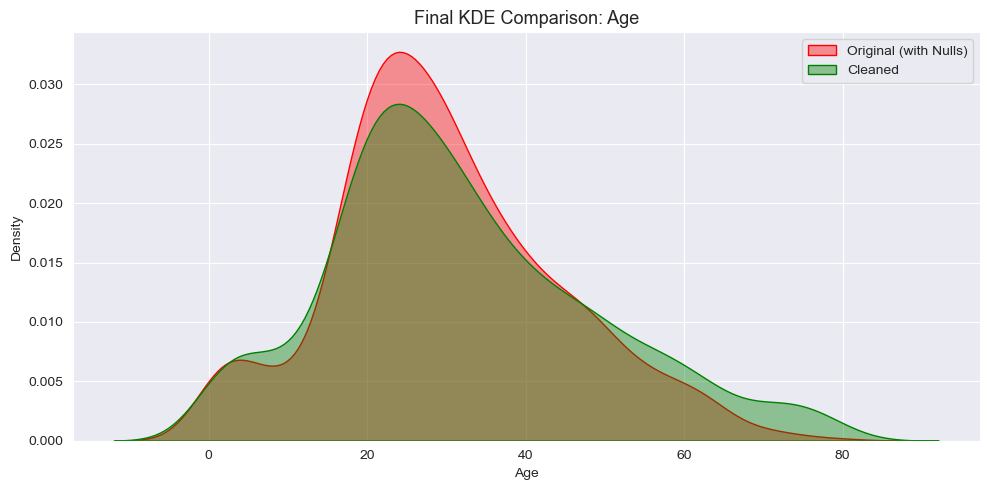

  'Age'
    Original Mean : 29.8811  |  Cleaned Mean : 31.8983
    Original Std  : 14.4135  |  Cleaned Std  : 16.9685
------------------------------------------------------------


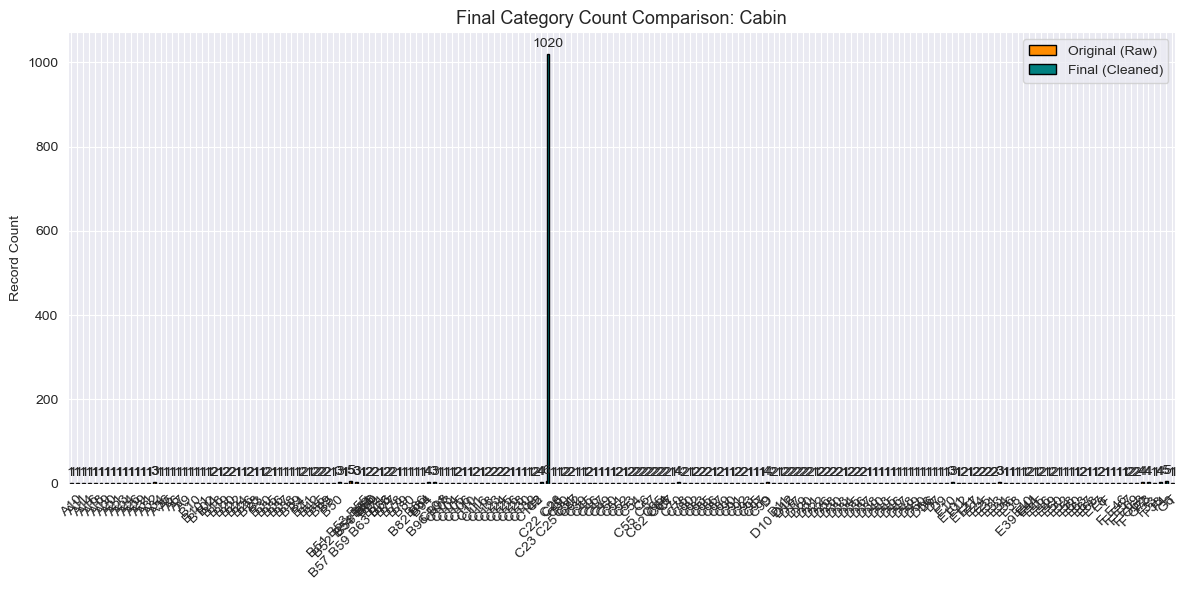

------------------------------------------------------------


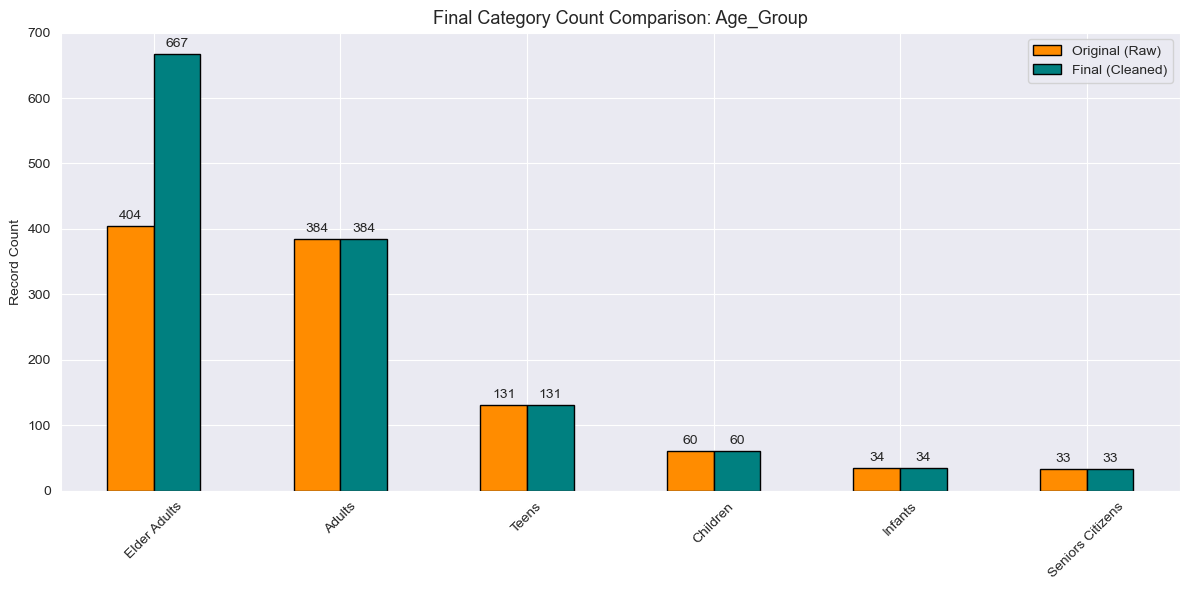

------------------------------------------------------------

✅ ALL DONE — Dataset is fully cleaned and null-free!


In [48]:
# STEP 1 — INITIAL DATASET INSPECTION

original = len(df)
original_df = df.copy()  # Backup data

print("=" * 60)
print(f"Total Rows    : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")
print("=" * 60)

# Detect numerical and categorical columns
numerical_cols   = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical Columns   :\n  {numerical_cols}")
print("-" * 60)
print(f"Categorical Columns :\n  {categorical_cols}")
print("-" * 60)

# Null summary 
nul     = df.isnull().sum()
nul_pct = df.isnull().mean() * 100

print(f"Null Value Counts (>1):\n{nul[nul > 1]}")
print("-" * 60)
print(f"Null Percentages  (>1%):\n{nul_pct[nul_pct > 1]}")
print("-" * 60)

# Split columns by 5% threshold
cols_less_5 = []
cols_more_5 = []

for var in df.columns:
    if 0 < nul_pct[var] <= 5:
        cols_less_5.append(var)
    elif nul_pct[var] > 5:
        cols_more_5.append(var)

print(f"Columns with > 5% Nulls : {cols_more_5}")
print("-" * 60)
print(f"Columns with ≤ 5% Nulls : {cols_less_5}")
print("-" * 60)

# HELPER — decide if a numerical column is binary / low-cardinality

def is_binary_or_low_cardinality(series, threshold=5):
    """Returns True if the column has very few unique values (binary, ordinal flags).
    We have set the threshold on 5 means when it will read column the column which is having values less than 5 are only
    read but value greater than 5 will be ignored."""
    return series.dropna().nunique() <= threshold


# =============================================================================
# STEP 2 — AUTO-FILL COLUMNS WITH ≤ 5% NULLS  (no user input needed)

new_df = df.copy()

print("\n" + "=" * 60)
print("AUTO-FILLING COLUMNS WITH ≤ 5% NULL DATA")
print("=" * 60)

for col in cols_less_5:

    if col in numerical_cols:
        if is_binary_or_low_cardinality(df[col]):
            # ✅ FIX: binary/low-cardinality → fill with MODE, not mean
            fill_val = df[col].mode()[0]
            fill_label = f"Mode ({fill_val})"
        else:
            fill_val  = df[col].mean()
            fill_label = f"Mean ({fill_val:.2f})"

        new_df[col] = new_df[col].fillna(fill_val)

        # Plot
        fig, ax = plt.subplots(figsize=(8, 4))
        if is_binary_or_low_cardinality(df[col]):
            # bar chart for binary/low-cardinality
            cnt = pd.DataFrame({
                'Original': df[col].value_counts(),
                'Filled'  : new_df[col].value_counts()
            }).fillna(0)
            cnt.plot(kind='bar', color=['skyblue', 'lightgreen'],
                     edgecolor='black', ax=ax)
            for c in ax.containers:
                ax.bar_label(c, padding=3)
            ax.set_title(f"Bar Chart (Auto-fill): {col}  [{fill_label}]")
            plt.xticks(rotation=0)
        else:
            sns.kdeplot(df[col],     ax=ax, color='red',   fill=True,
                        alpha=0.4, label='Original')
            sns.kdeplot(new_df[col], ax=ax, color='green', fill=True,
                        alpha=0.4, label=f'Filled [{fill_label}]')
            ax.set_title(f"KDE (Auto-fill): {col}")
            ax.legend()

        plt.tight_layout()
        plt.show()
        print(f"  ✅ '{col}' filled with {fill_label}")
        print("-" * 60)

    elif col in categorical_cols:
        mode_val    = df[col].mode()[0]
        new_df[col] = new_df[col].fillna(mode_val)

        cnt = pd.DataFrame({
            'Original': df[col].value_counts(),
            'Filled'  : new_df[col].value_counts()
        }).fillna(0)

        fig, ax = plt.subplots(figsize=(10, 5))
        cnt.plot(kind='bar', color=['skyblue', 'lightgreen'],
                 edgecolor='black', ax=ax)
        for c in ax.containers:
            ax.bar_label(c, padding=3)

        ax.set_title(f"Bar Chart (Auto-fill Mode): {col}")
        ax.set_xlabel("Categories")
        ax.set_ylabel("Count")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        print(f"  ✅ '{col}' filled with Mode = '{mode_val}'")
        print("-" * 60)


# =============================================================================
# STEP 3 — INTERACTIVE FILL FOR COLUMNS WITH > 5% NULLS
# =============================================================================

print("\n" + "=" * 60)
print("EVALUATING COLUMNS WITH > 5% NULL DATA  (user input required)")
print("=" * 60)

for col in cols_more_5:
    print(f"\n{'=' * 60}")
    print(f"  COLUMN : {col}")
    print(f"{'=' * 60}")

    # ------------------------------------------------------------------
    # NUMERICAL
    # ------------------------------------------------------------------
    if col in numerical_cols:

        binary_col = is_binary_or_low_cardinality(df[col])

        mean_val   = df[col].mean()
        median_val = df[col].median()
        mode_val   = df[col].mode()[0]
        min_val    = df[col].min()
        max_val    = df[col].max()
        null_count = df[col].isnull().sum()

        series_mean   = df[col].fillna(mean_val)
        series_median = df[col].fillna(median_val)
        series_mode   = df[col].fillna(mode_val)

        # ✅ FIX: random fill — use valid category values for binary cols
        if binary_col:
            random_vals = np.random.choice(
                df[col].dropna().unique(), size=null_count
            )
        else:
            random_vals = np.random.uniform(min_val, max_val, size=null_count)

        series_random = df[col].copy()
        null_mask = series_random.isnull()
        series_random.loc[null_mask] = random_vals

        # ---- PLOT --------------------------------------------------
        fig, axes = plt.subplots(1, 4, figsize=(22, 6))
        fig.suptitle(
            f"Imputation Comparison for: {col}  "
            f"({'Binary/Low-Cardinality' if binary_col else 'Continuous'})",
            fontsize=16
        )

        pairs = [
            (axes[0], series_mean,   'green',  'Mean Fill',   f'Mean ({mean_val:.2f})'),
            (axes[1], series_median, 'blue',   'Median Fill', f'Median ({median_val:.2f})'),
            (axes[2], series_mode,   'orange', 'Mode Fill',   f'Mode ({mode_val})'),
            (axes[3], series_random, 'purple', 'Random Fill', 'Random'),
        ]

        for ax, series, color, title, lbl in pairs:
            if binary_col:
                # ✅ FIX: bar chart for binary/low-cardinality columns
                cnt = pd.DataFrame({
                    'Original': df[col].value_counts(),
                    lbl       : series.value_counts()
                }).fillna(0)
                cnt.plot(kind='bar', color=['salmon', color],
                         edgecolor='black', ax=ax, alpha=0.7)
                for c in ax.containers:
                    ax.bar_label(c, padding=2, fontsize=8)
                ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
            else:
                # KDE for continuous columns
                sns.kdeplot(df[col], ax=ax, color='red',  fill=True,
                            alpha=0.4, label='Original')
                sns.kdeplot(series,  ax=ax, color=color, fill=True,
                            alpha=0.4, label=lbl)
                ax.legend(fontsize=8)

            ax.set_title(title, fontsize=11)

        plt.tight_layout()
        plt.show()

        # Std-dev comparison (skip for binary — not meaningful)
        if not binary_col:
            print(f"\nStd Dev Comparison for '{col}'  (closer to Original = better):")
            print(f"  Original : {df[col].std():.4f}")
            print(f"  Mean     : {series_mean.std():.4f}")
            print(f"  Median   : {series_median.std():.4f}")
            print(f"  Mode     : {series_mode.std():.4f}")
            print(f"  Random   : {series_random.std():.4f}")
        else:
            print(f"\n'{col}' is binary/low-cardinality — "
                  f"std dev not shown. Recommend: mode or random.")

        choice = input(
            f"\nFill '{col}' with which strategy? "
            f"(mean / median / mode / random) : "
        ).strip().lower()

        if choice == 'mean':
            new_df[col] = series_mean
        elif choice == 'median':
            new_df[col] = series_median
        elif choice == 'mode':
            new_df[col] = series_mode
        elif choice == 'random':
            new_df[col] = series_random
        else:
            print("  ⚠️  Invalid choice — defaulting to Median.")
            new_df[col] = series_median

        print(f"  ✅ '{col}' filled.")

    # ------------------------------------------------------------------
    # CATEGORICAL
    # ------------------------------------------------------------------
    elif col in categorical_cols:

        mode_val      = df[col].mode()[0]
        series_mode   = df[col].fillna(mode_val)
        series_missing = df[col].fillna('Missing_Data')

        cnt = pd.DataFrame({
            'Original'           : df[col].value_counts(),
            'Mode Imputed'       : series_mode.value_counts(),
            'Missing Placeholder': series_missing.value_counts()
        }).fillna(0)

        fig, ax = plt.subplots(figsize=(12, 6))
        cnt.plot(kind='bar',
                 color=['skyblue', 'lightgreen', 'salmon'],
                 edgecolor='black', ax=ax)
        for c in ax.containers:
            ax.bar_label(c, padding=3)

        ax.set_title(f"Categorical Imputation Comparison: {col}", fontsize=13)
        ax.set_xlabel("Categories")
        ax.set_ylabel("Count")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        choice = input(
            f"\nFill '{col}' with which strategy? "
            f"(mode / missing) : "
        ).strip().lower()

        if choice == 'mode':
            new_df[col] = series_mode
            print(f"  ✅ '{col}' filled with Mode = '{mode_val}'")
        else:
            new_df[col] = series_missing
            print(f"  ✅ '{col}' filled with 'Missing_Data' placeholder.")

    print("-" * 60)


# =============================================================================
# STEP 4 — COMMIT CHANGES BACK TO df
# =============================================================================

df = new_df


print("\n" + "=" * 60)
print("NULL CHECK AFTER FILLING ALL COLUMNS:")
print(df.isnull().sum().to_string())
print("=" * 60)


# =============================================================================
# STEP 5 — FINAL BEFORE vs AFTER DISTRIBUTION COMPARISON
# =============================================================================

print("\n" + "=" * 60)
print("FINAL DISTRIBUTION COMPARISON  (Original vs Cleaned)")
print("=" * 60)

filled_cols = cols_less_5 + cols_more_5

for col in filled_cols:

    if col in numerical_cols:
        binary_col = is_binary_or_low_cardinality(original_df[col])

        if binary_col:
            # ✅ FIX: bar chart for binary final comparison too
            cnt = pd.DataFrame({
                'Original (Raw)' : original_df[col].value_counts(),
                'Cleaned'        : df[col].value_counts()
            }).fillna(0)

            fig, ax = plt.subplots(figsize=(8, 5))
            cnt.plot(kind='bar',
                     color=['darkorange', 'teal'],
                     edgecolor='black', ax=ax)
            for c in ax.containers:
                ax.bar_label(c, padding=3)
            ax.set_title(f"Final Comparison (Binary): {col}", fontsize=13)
            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.show()

        else:
            fig, ax = plt.subplots(figsize=(10, 5))
            sns.kdeplot(original_df[col], ax=ax, color='red',   fill=True,
                        alpha=0.4, label='Original (with Nulls)')
            sns.kdeplot(df[col],          ax=ax, color='green', fill=True,
                        alpha=0.4, label='Cleaned')
            ax.set_title(f"Final KDE Comparison: {col}", fontsize=13)
            ax.legend()
            plt.tight_layout()
            plt.show()

        print(f"  '{col}'")
        print(f"    Original Mean : {original_df[col].mean():.4f}  |  "
              f"Cleaned Mean : {df[col].mean():.4f}")
        print(f"    Original Std  : {original_df[col].std():.4f}  |  "
              f"Cleaned Std  : {df[col].std():.4f}")
        print("-" * 60)

    elif col in categorical_cols:
        cnt = pd.DataFrame({
            'Original (Raw)': original_df[col].value_counts(),
            'Final (Cleaned)': df[col].value_counts()
        }).fillna(0)

        fig, ax = plt.subplots(figsize=(12, 6))
        cnt.plot(kind='bar',
                 color=['darkorange', 'teal'],
                 edgecolor='black', ax=ax)
        for c in ax.containers:
            ax.bar_label(c, padding=3)

        ax.set_title(f"Final Category Count Comparison: {col}", fontsize=13)
        ax.set_ylabel("Record Count")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        print("-" * 60)

print("\n✅ ALL DONE — Dataset is fully cleaned and null-free!")

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Age_Group',
       'family_size', 'family_type', 'surname', 'Title_Grouped',
       'ticket_type'],
      dtype='object')

In [6]:
# Setting some styles.

sns.set_style("darkgrid")
sns.set_palette("viridis")

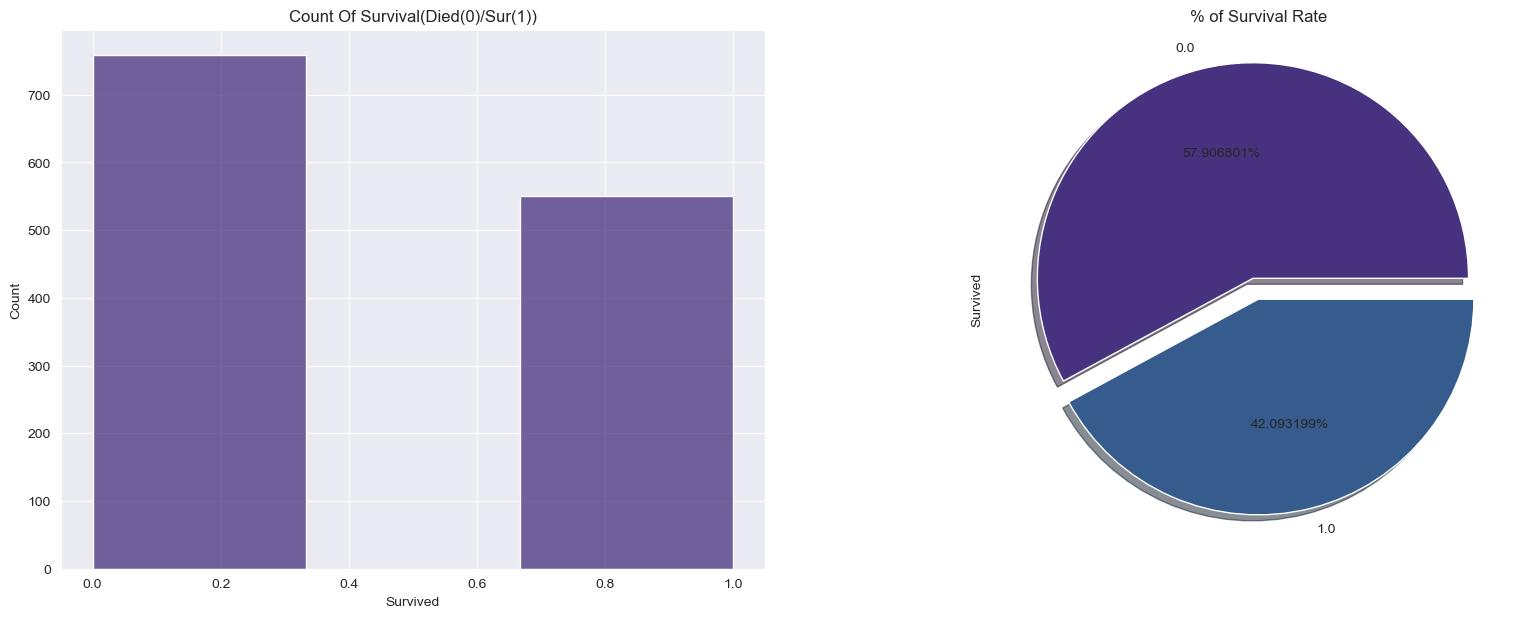

In [7]:
# Analysis of Total Survived.

fig,ax = plt.subplots(1,2,figsize = (20,7))

sns.histplot(data = df, x = 'Survived', stat="count", bins=3, multiple='stack',ax=ax[0])

df['Survived'].value_counts().plot.pie(explode=[0.1,0],autopct="%1.6f%%",shadow=True, ax=ax[1])

ax[0].set_title("Count Of Survival(Died(0)/Sur(1))")
ax[1].set_title("% of Survival Rate")
plt.show()

**We Observed from the above plots after filling the null values.**
- Only 42.9% of passengers survived the disaster.
- While 57.1% of Passengers didn't Survived!

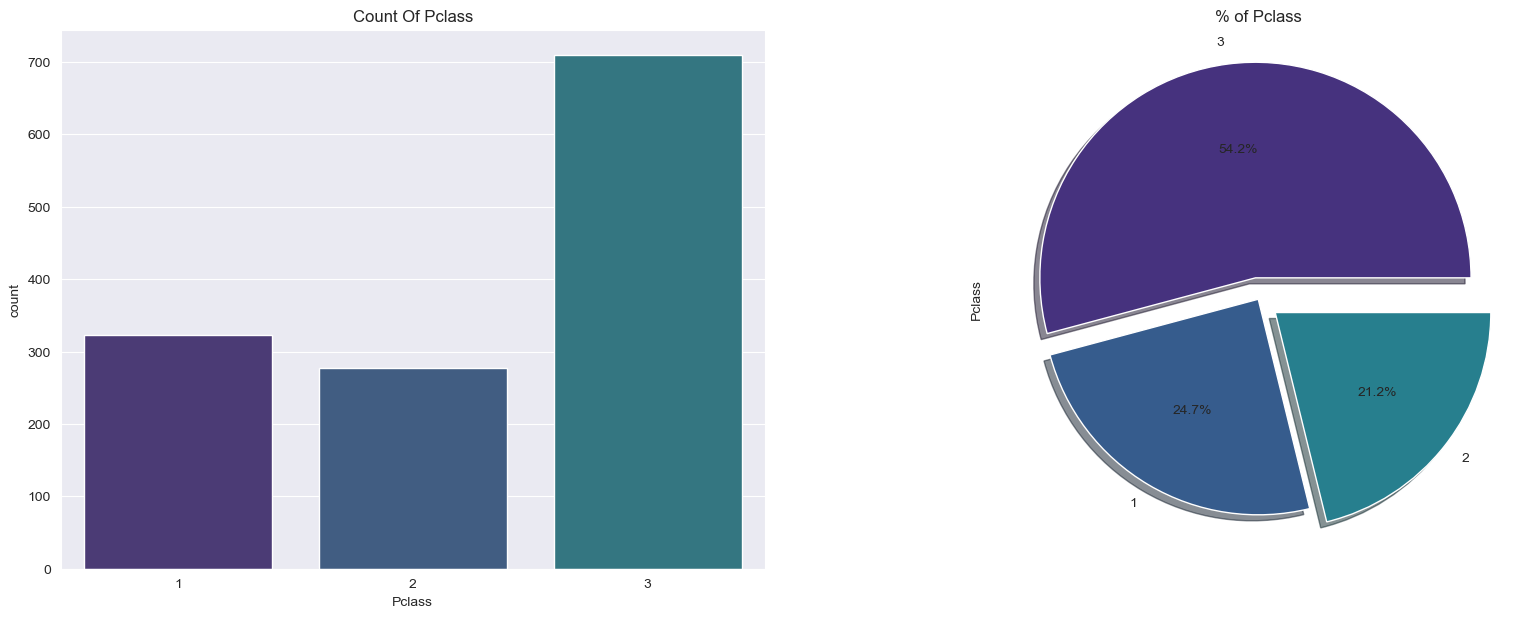

In [8]:
# Anaysis on Pclass


fig , ax = plt.subplots(1,2,figsize=(20,7))

sns.countplot(data=df,x='Pclass',ax=ax[0])
df['Pclass'].value_counts().plot.pie(shadow=True,autopct="%1.1f%%",ax=ax[1],explode=[0.1,0,0.1])

ax[0].set_title("Count Of Pclass")
ax[1].set_title("% of Pclass")
plt.show()

**We observed in the above plot:**
- There are 54.2% passengers who were in 3rd class.
- There are 21.2% passengers who were in 2nd class.
- There are 24.7% passengers who were in 1st class.

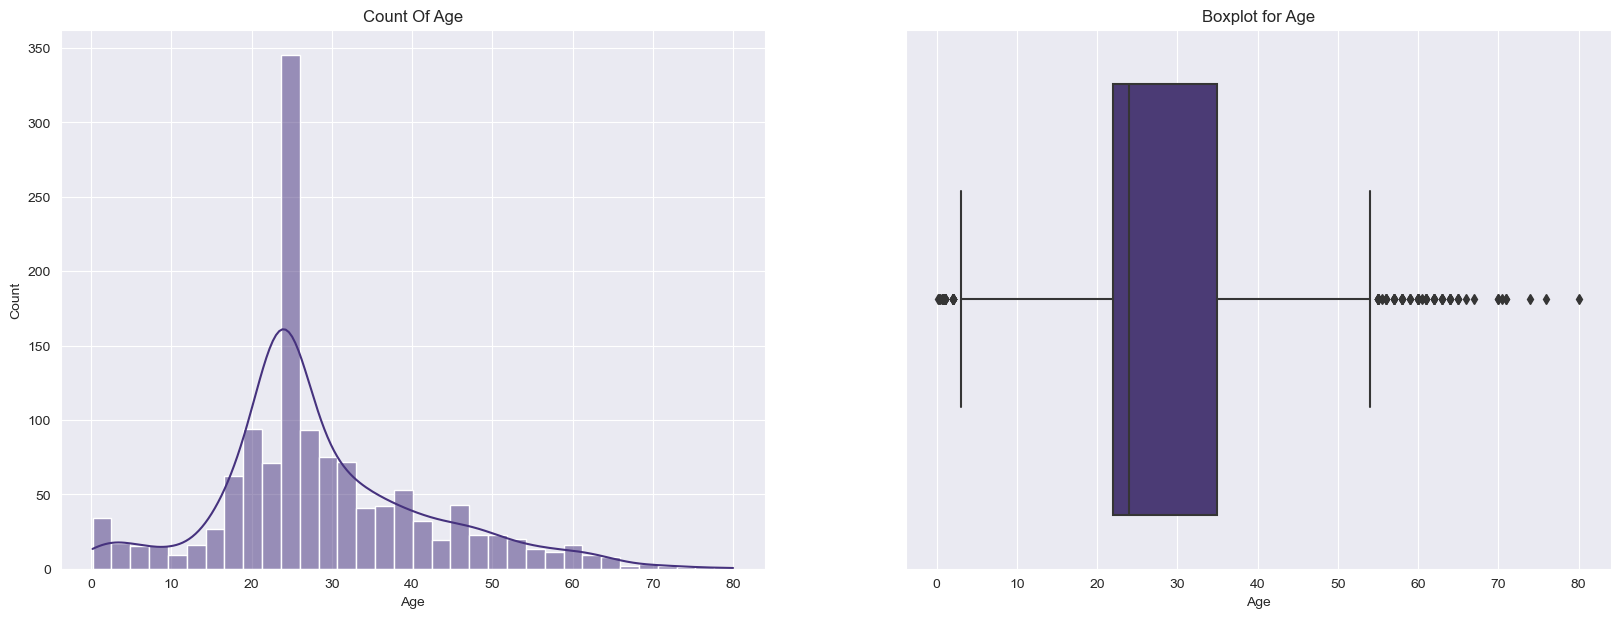

In [9]:
# Analysis of Age

fig,ax = plt.subplots(1,2,figsize = (20,7))
sns.histplot(data=df,x="Age",ax=ax[0],kde=True)
sns.boxplot(data=df,x="Age",ax=ax[1])
ax[0].set_title("Count Of Age")
ax[1].set_title("Boxplot for Age")
plt.show()

**We observed in the above plot:**
- The passengers between the age 15 to 45 are more on the Titanic.
- There are several outliers present in the Age column.

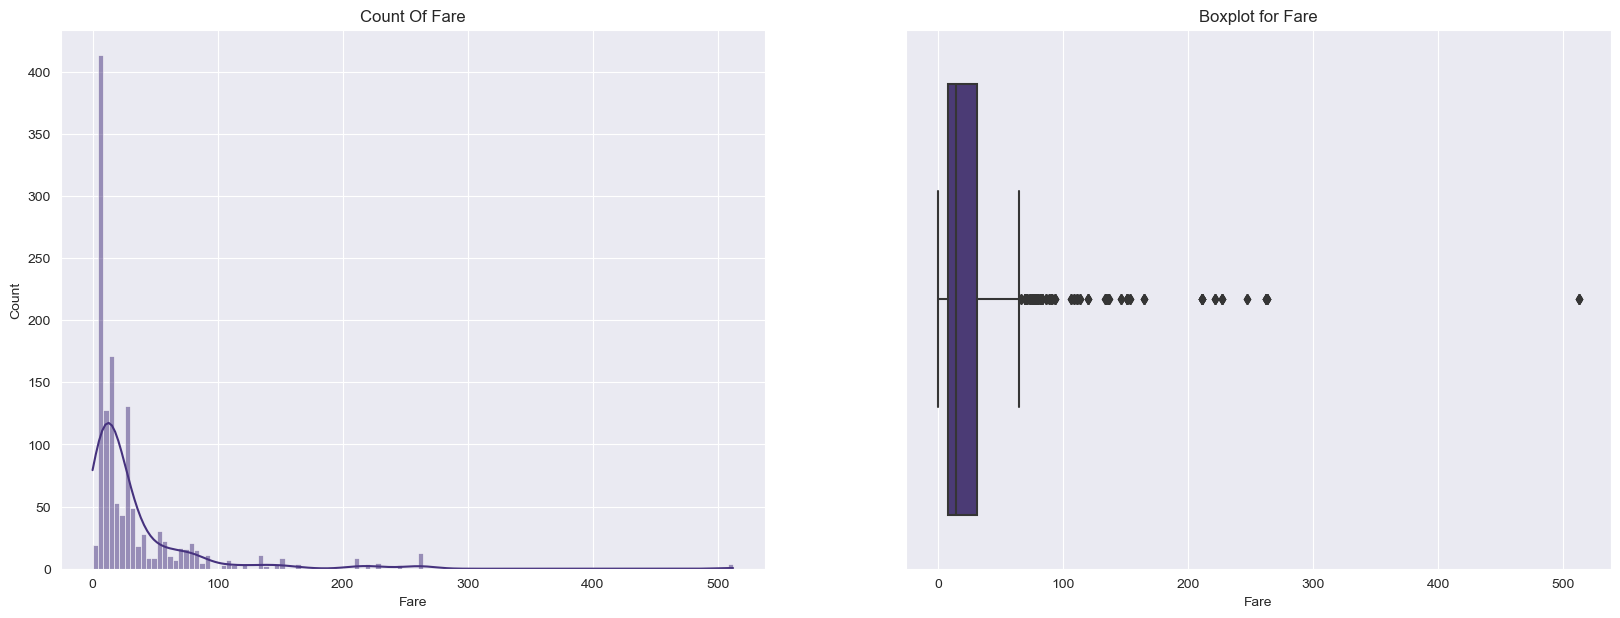

In [10]:
# Analysis on Fare


fig,ax = plt.subplots(1,2,figsize=(20,7))
sns.histplot(data=df,x='Fare',ax=ax[0],kde=True)
sns.boxplot(data=df,x='Fare',ax=ax[1])

ax[0].set_title("Count Of Fare")
ax[1].set_title("Boxplot for Fare")
plt.show()

**What we observed in above plots:**
- The histogram for *Fare* is quite skewed. Let is observe some facts about *Fare*.

In [11]:
max_fare , min_fare = df["Fare"].max(),df['Fare'].min()

print(f"Number of Passengers who paid {min_fare}:- ",df[df["Fare"]==min_fare].shape[0])
print(f"Number of Passengers who paid {max_fare:.2f}:- ",df[df["Fare"]==max_fare].shape[0])
print(f"Fare given by maximum number of passengers :- ",list(dict(df["Fare"].value_counts()).keys())[0])

Number of Passengers who paid 0.0:-  17
Number of Passengers who paid 512.33:-  4
Fare given by maximum number of passengers :-  8.05


**Observation:-**
- Only 4 passengers paid 512 dollars to be on Titanic.
- 17 Passengers paid no Fare to be on Titanic.
- Maximum passengers paid approximately 8 dollars.

In [12]:
# People who didn't paid a single dollar to be on Titanic.

print(f"Total Passengers: {len(df[df['Fare']==min_fare])}")
df[df['Fare']==min_fare]

Total Passengers: 17


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Group,family_size,family_type,surname,Title_Grouped,ticket_type
179,180,0.0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,C23 C25 C27,S,Elder Adults,1,Alone,Leonard,Mr,Prefix
263,264,0.0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0,B94,S,Elder Adults,1,Alone,Harrison,Mr,Numeric
271,272,1.0,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,C23 C25 C27,S,Adults,1,Alone,Tornquist,Mr,Prefix
277,278,0.0,2,"Parkes, Mr. Francis ""Frank""",male,24.0,0,0,239853,0.0,C23 C25 C27,S,Elder Adults,1,Alone,Parkes,Mr,Numeric
302,303,0.0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,C23 C25 C27,S,Teens,1,Alone,Johnson,Mr,Prefix
413,414,0.0,2,"Cunningham, Mr. Alfred Fleming",male,24.0,0,0,239853,0.0,C23 C25 C27,S,Elder Adults,1,Alone,Cunningham,Mr,Numeric
466,467,0.0,2,"Campbell, Mr. William",male,24.0,0,0,239853,0.0,C23 C25 C27,S,Elder Adults,1,Alone,Campbell,Mr,Numeric
481,482,0.0,2,"Frost, Mr. Anthony Wood ""Archie""",male,24.0,0,0,239854,0.0,C23 C25 C27,S,Elder Adults,1,Alone,Frost,Mr,Numeric
597,598,0.0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,C23 C25 C27,S,Elder Adults,1,Alone,Johnson,Mr,Prefix
633,634,0.0,1,"Parr, Mr. William Henry Marsh",male,24.0,0,0,112052,0.0,C23 C25 C27,S,Elder Adults,1,Alone,Parr,Mr,Numeric


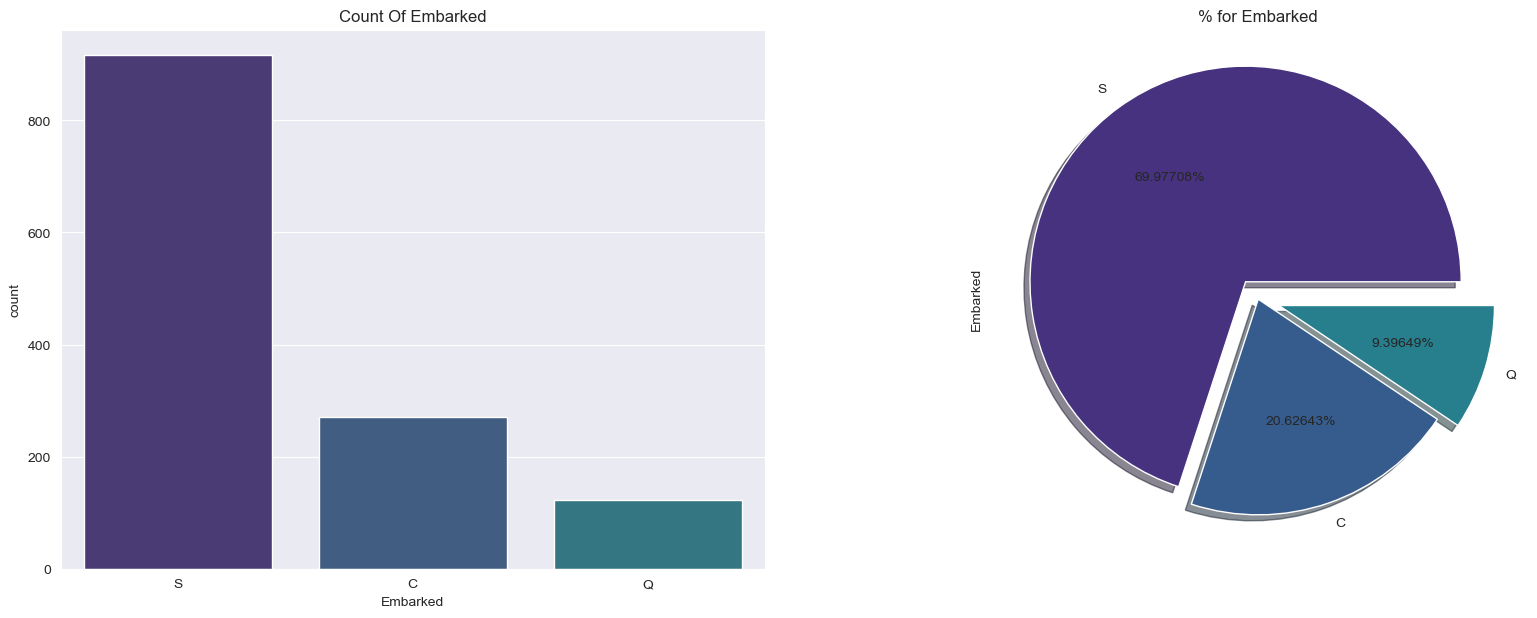

In [13]:
# Analysis on Embarked.

fig,ax = plt.subplots(1,2,figsize=(20,7))
sns.countplot(data=df,x="Embarked",ax=ax[0])
df['Embarked'].value_counts().plot.pie(ax=ax[1],autopct="%1.5f%%",explode=[0.1,0,0.1],shadow=True)

ax[0].set_title("Count Of Embarked")
ax[1].set_title("% for Embarked")
plt.show()

**Observation we saw in above chart:-**
- More than 800 Passengers get from the Southampton city on the Titanic make a total of 69.9% of total Passengers.
- Then comes Cherbourg 20.7% Almost 250 Passengers.
- Atlast comes Queenstown 9.4% i.e. approx 150 Passengers.

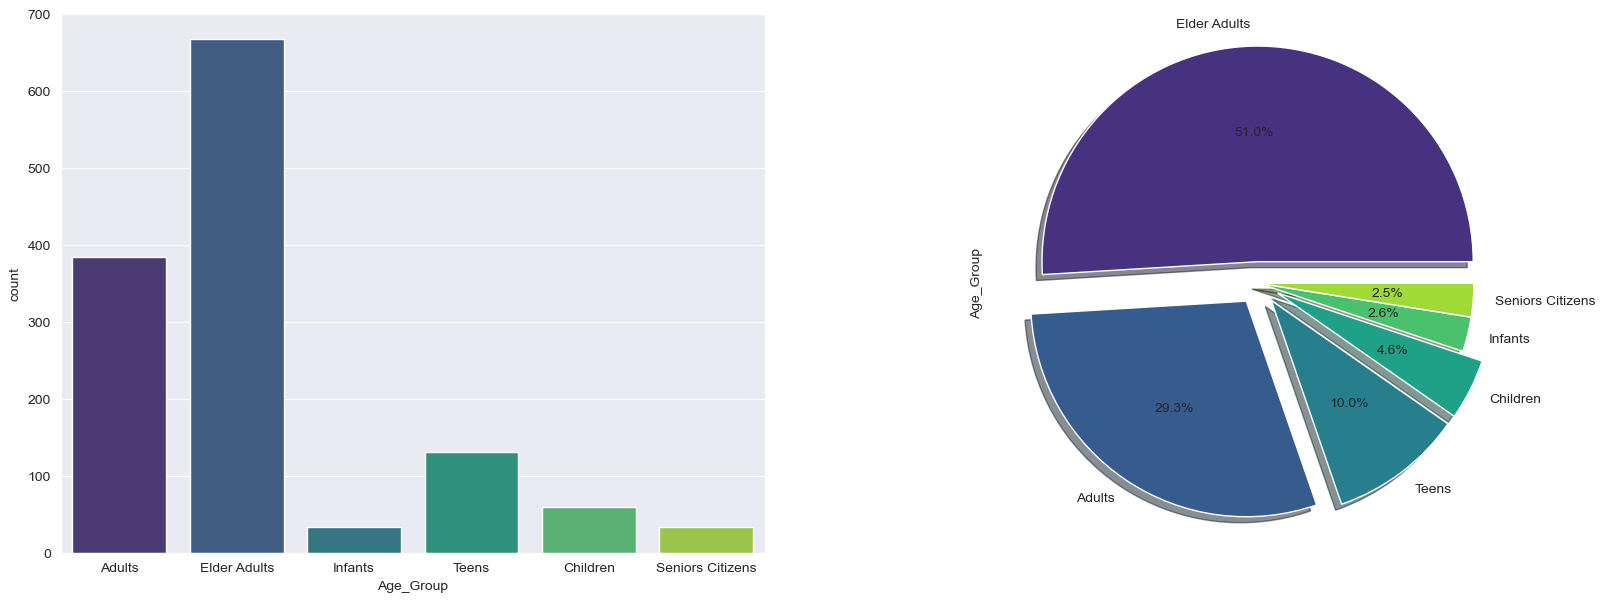

In [14]:
# Analysis on Age_Group.

fig,ax = plt.subplots(1,2,figsize=(20,7))
sns.countplot(data=df,x="Age_Group",ax=ax[0])
df['Age_Group'].value_counts().plot.pie(ax=ax[1],explode=[0.1,0.1,0.1,0.1,0,0],autopct="%1.1f%%",shadow=True)

plt.show()

**Observation From Above Chart:-**
- 31-60 --> Elder Adults - 404 (38.6%)
- 20-30 --> Adults - 384 (36.7%)
- 13-19 --> Teens - 131 (12.5%)
- 3-12 --> Children - 60 (5.7%)
- < 2   -> Infants -34 (3.3%)
- 61+   --> Senior Citizens - 33 (3.2%)

0    891
1    319
2     42
4     22
3     20
8      9
5      6
Name: SibSp, dtype: int64


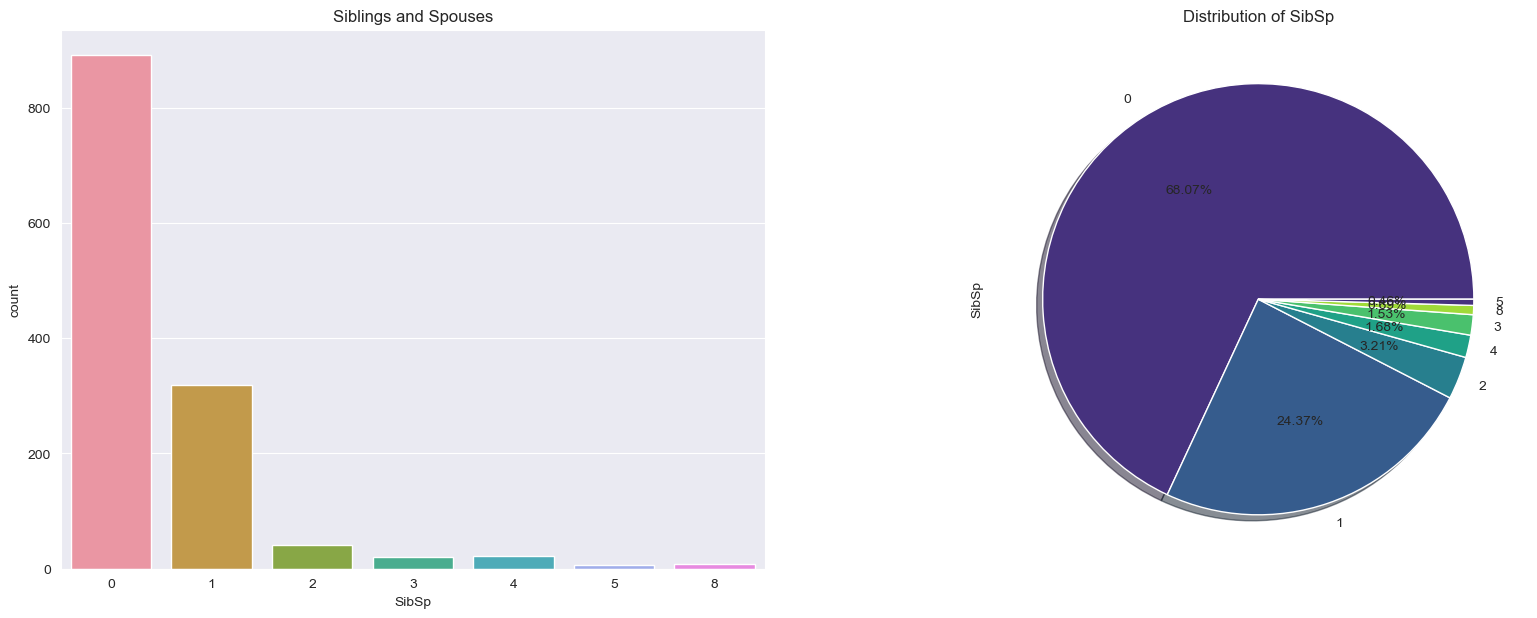

In [15]:
# Analysis on  SibSp.

fig,ax = plt.subplots(1,2,figsize=(20,7))

# SibSp:- 
sns.countplot(data=df,x='SibSp',ax=ax[0]).set_title("Siblings and Spouses")
df['SibSp'].value_counts().plot.pie(ax=ax[1],shadow=True,title='Distribution of SibSp',autopct="%1.2f%%")
x = df['SibSp'].value_counts()
print(x)
plt.show()

**Observation:**
- Around **68.07%** passengers were without SibSp's.
- Around **23.46%** passengers were with SibSp's.
- Approximately **7 to 8%** passengers were with SibSp's.

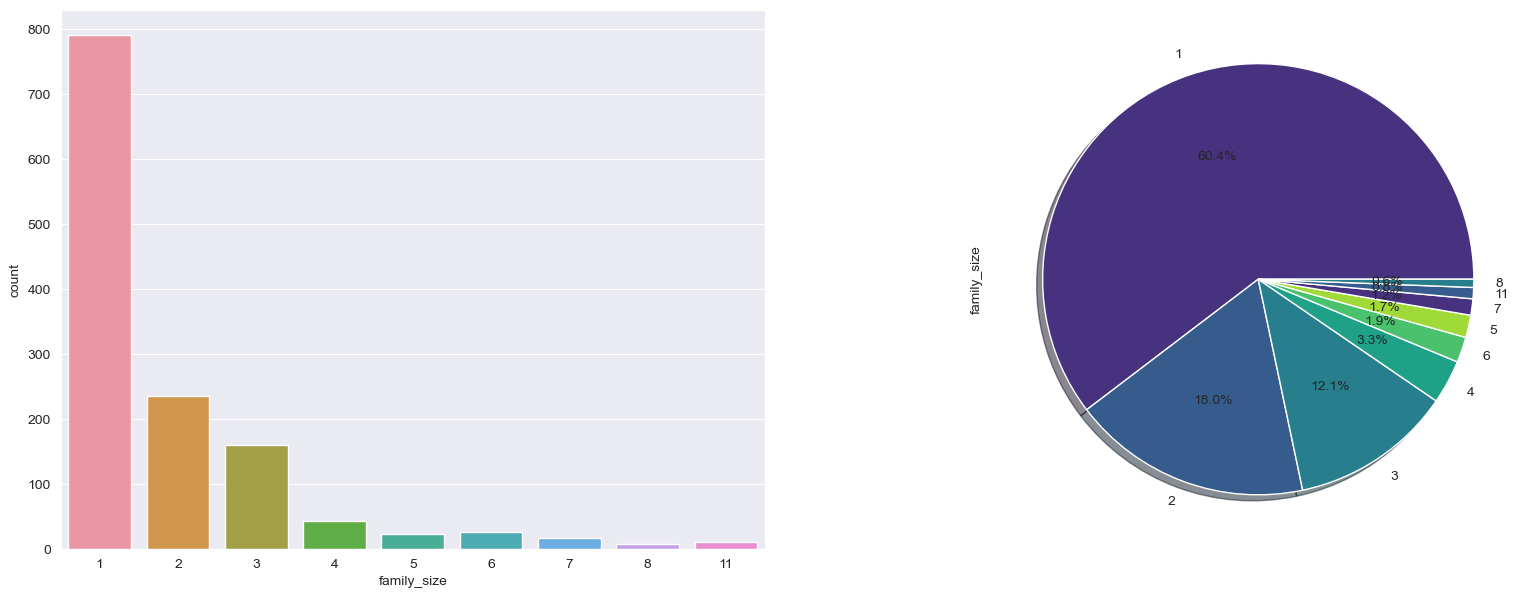

In [16]:
# Analysis on Family Size.

fig,ax = plt.subplots(1,2,figsize=(20,7))
sns.countplot(data=df,x="family_size",ax=ax[0])
df['family_size'].value_counts().plot.pie(ax=ax[1],autopct="%1.1f%%",shadow=True)

plt.show()

**Observations From above Graphs:-**
- A Single passengers are holding a total of 60.4% (790) of space on Titanic.
- Passengers having someone with them holds 18% (235) of space.
- Passengers having a small family or 3 members holds 12.1% (159) of space.
- Passengers with 4 family members holds 3.3% (43) of space.
- Passengers with 5 to 11 familly members holds approx 4 to 5% of total space on the ship.

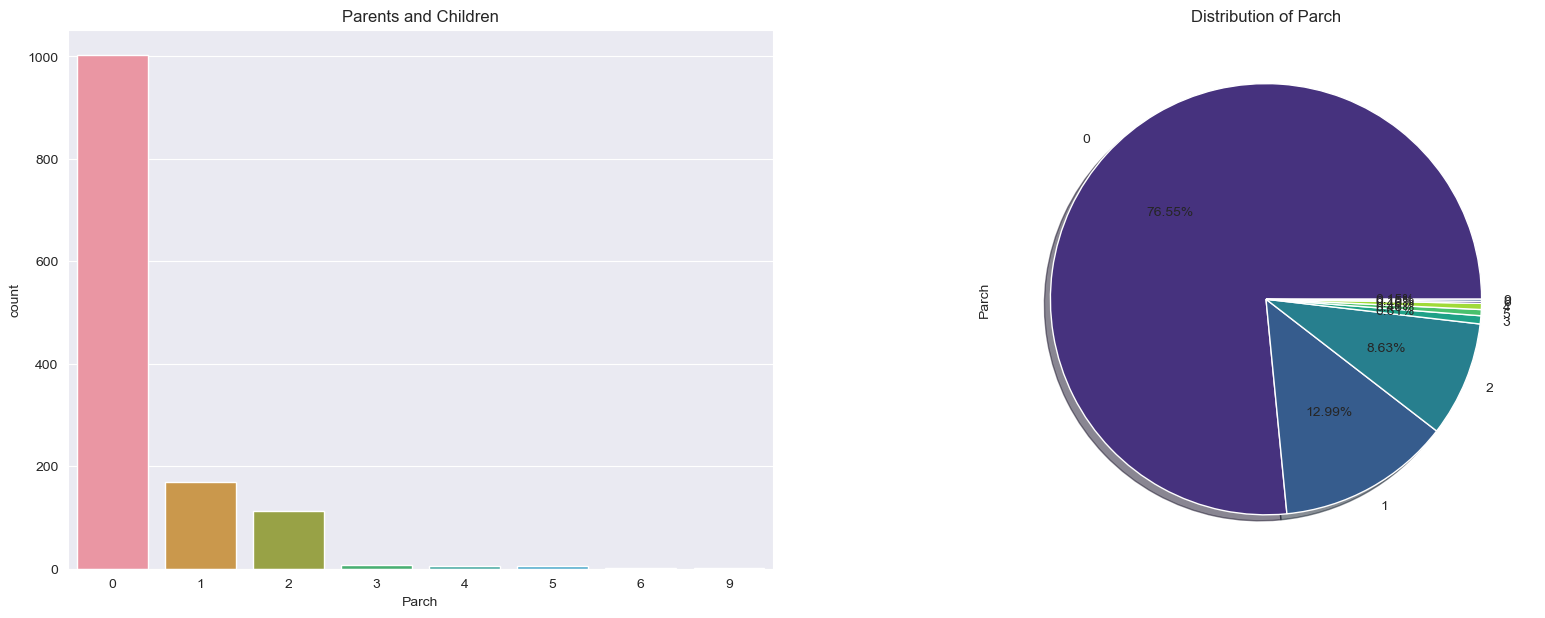

In [17]:
# Analysis on Parch

fig,ax = plt.subplots(1,2,figsize=(20,7))
sns.countplot(data=df,x="Parch",ax=ax[0]).set_title("Parents and Children")
df['Parch'].value_counts().plot.pie(ax=ax[1],shadow=True,title='Distribution of Parch',autopct="%1.2f%%")

plt.show()

**Observation:**
- Around **76.55%** passengers were without Parents and Children.
- Around **13%** passengers were with 1 Parents and Children.
- Around **8.63%** Were with 2 Parch.

Alone     790
Double    235
Small     202
Large      82
Name: family_type, dtype: int64


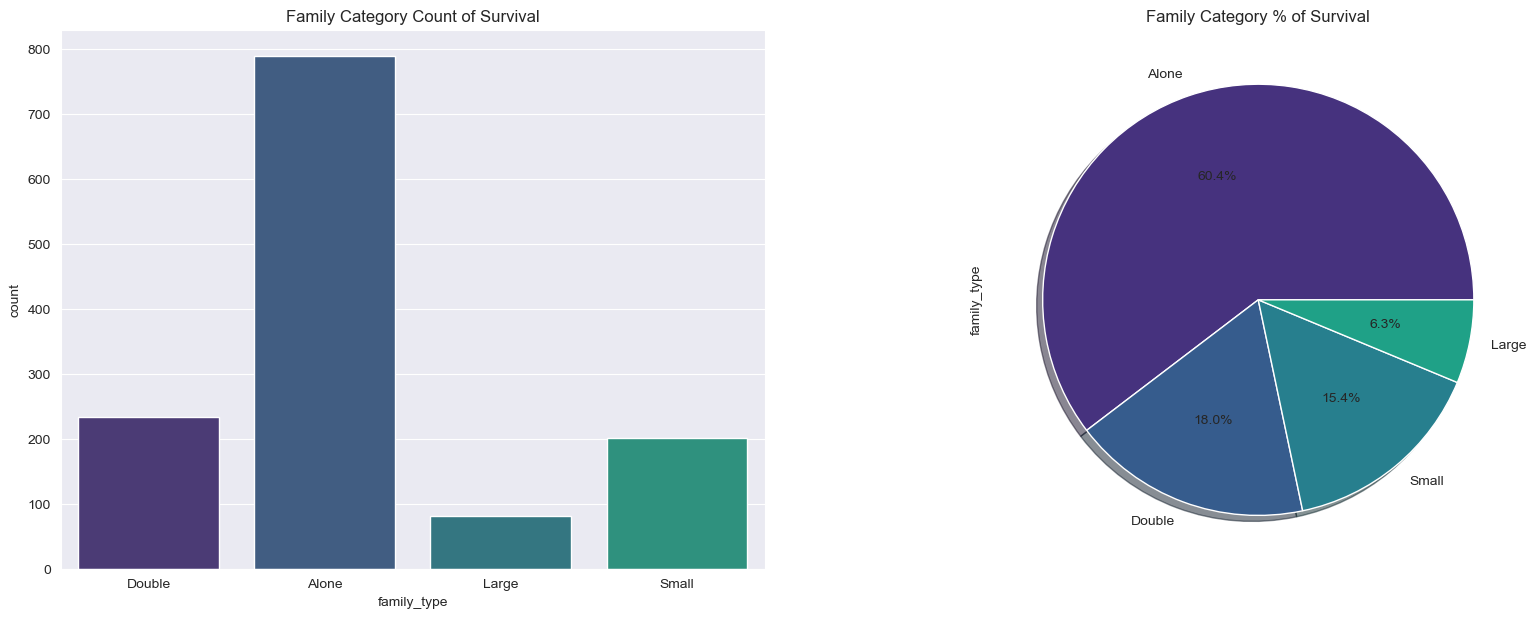

In [54]:
# Analysis on Family Type.

fig,ax = plt.subplots(1,2,figsize=(20,7))
sns.countplot(data=df,x="family_type",ax=ax[0])
df['family_type'].value_counts().plot.pie(ax=ax[1],autopct="%1.1f%%",shadow=True)
ax[0].set_title("Family Category Count of Survival")
ax[1].set_title("Family Category % of Survival")

x = df['family_type'].value_counts()
print(x)
plt.show()

**Observations on Above Chart:-**
- Passengers travelling Alone was total 790 which holds 60.4% of total space on the ship.
- Passengers having someone with them has total 235 which holds 18% of total space on the ship.
- Passengers having a small family less than 5 members holds 15.4% of the total space on the ship.
- Passengers having more than 5 family members were 82 which holds 6.3% of total space on the ship.

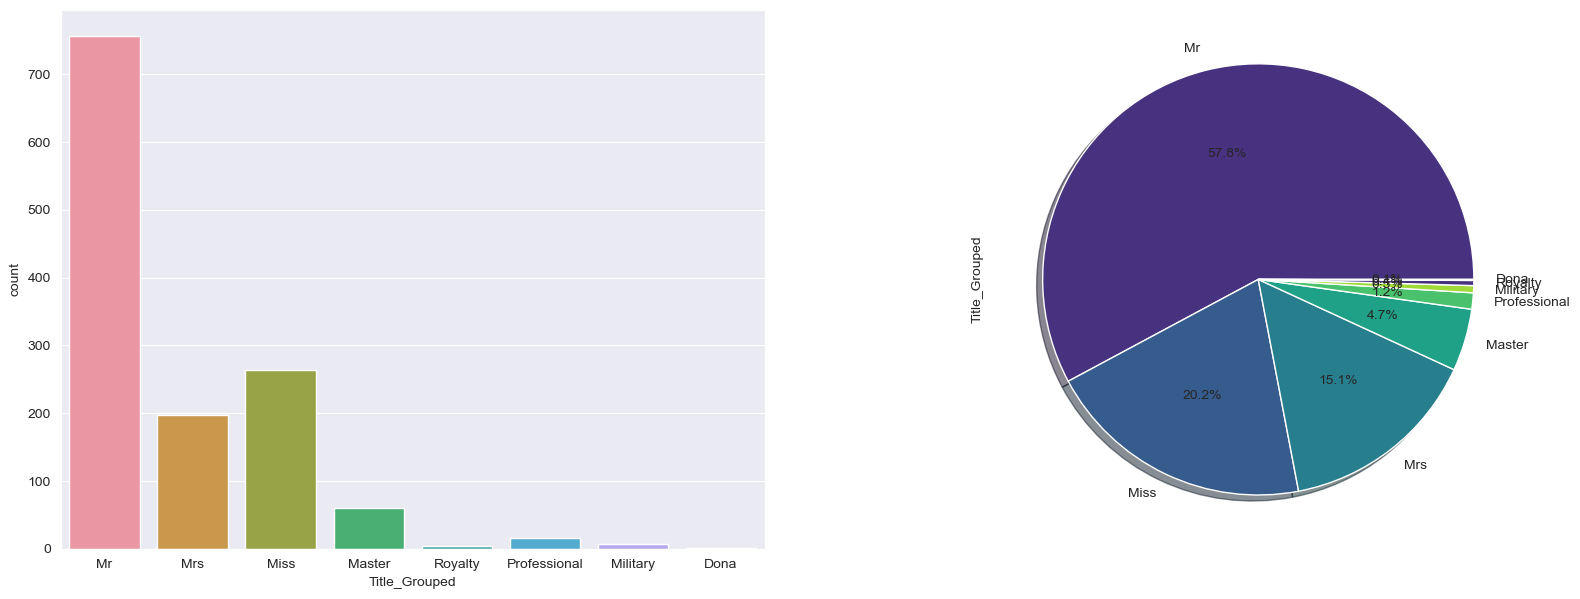

In [19]:
# Analysis on Title Group.

fig,ax = plt.subplots(1,2,figsize=(20,7))
sns.countplot(data=df,x="Title_Grouped",ax=ax[0])
df['Title_Grouped'].value_counts().plot.pie(ax=ax[1],autopct="%1.1f%%",shadow=True)

plt.show()

**Observation from above chart:-**
- Total Males were 757 which holds 57.8%
- Total Unmarried Females were 264 holds 20.2%
- Total Married Females were 198 holds 15.1%
- Total Master Were 61 holds 4.7%
- Total Professional were 16 holds 1.2%
- Total Military Officials were 7 holds 1.2%
- Total Royalty were 5 holds 0.3 %
- There was single Dona.

# ---------------------- Bivariate Analysis ----------------------

- **CAT vs CAT**

Pclass            1          2          3
Survived                                 
0.0       10.389610  10.389610  37.127578
1.0       14.285714  10.771581  17.035905


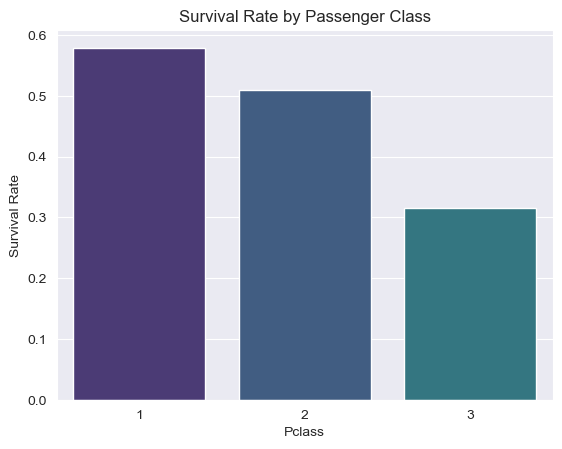

In [20]:
# Survival by Pclass.

ct = pd.crosstab(df['Survived'],df['Pclass'],normalize=True)*100
print(ct)

sns.barplot(data=df, x='Pclass', y='Survived',ci=False)
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

**Observation:-**
- 1st Pclass was saved the most followed by 2nd class and then 3rd Pclass.

Survived        0.0        1.0
Sex                           
female    33.476395  66.523605
male      71.411625  28.588375


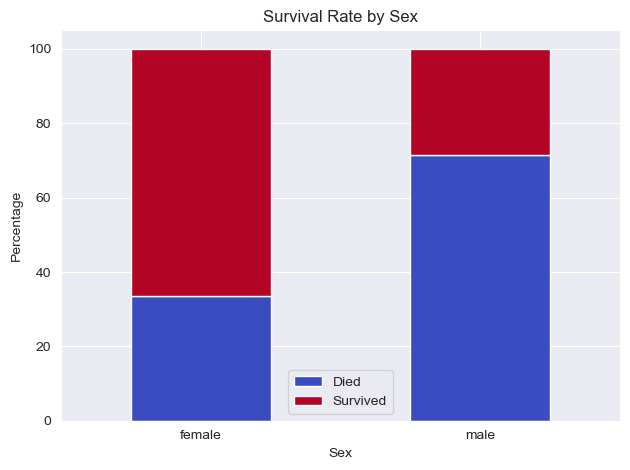

In [21]:
# Survival by Gender

ct = pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100
print(ct)
ct.plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title('Survival Rate by Sex')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(['Died', 'Survived'])
plt.tight_layout()
plt.show()

### Observation:- 

- More number of males are deceased in that incident and females were saved.

In [22]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Age_Group',
       'family_size', 'family_type', 'surname', 'Title_Grouped',
       'ticket_type'],
      dtype='object')

Embarked
S    38.318777
Q    43.902439
C    54.074074
Name: Survived, dtype: float64
-----------------------------------
Age_Group
Seniors Citizens    33.333333
Elder Adults        40.479760
Adults              41.927083
Teens               43.511450
Children            53.333333
Infants             58.823529
Name: Survived, dtype: float64
-----------------------------------
family_type
Large     21.951220
Alone     36.329114
Small     54.950495
Double    57.446809
Name: Survived, dtype: float64
-----------------------------------
Title_Grouped
Professional     25.000000
Mr               26.684280
Military         28.571429
Master           54.098361
Royalty          60.000000
Miss             64.393939
Mrs              68.686869
Dona            100.000000
Name: Survived, dtype: float64
-----------------------------------


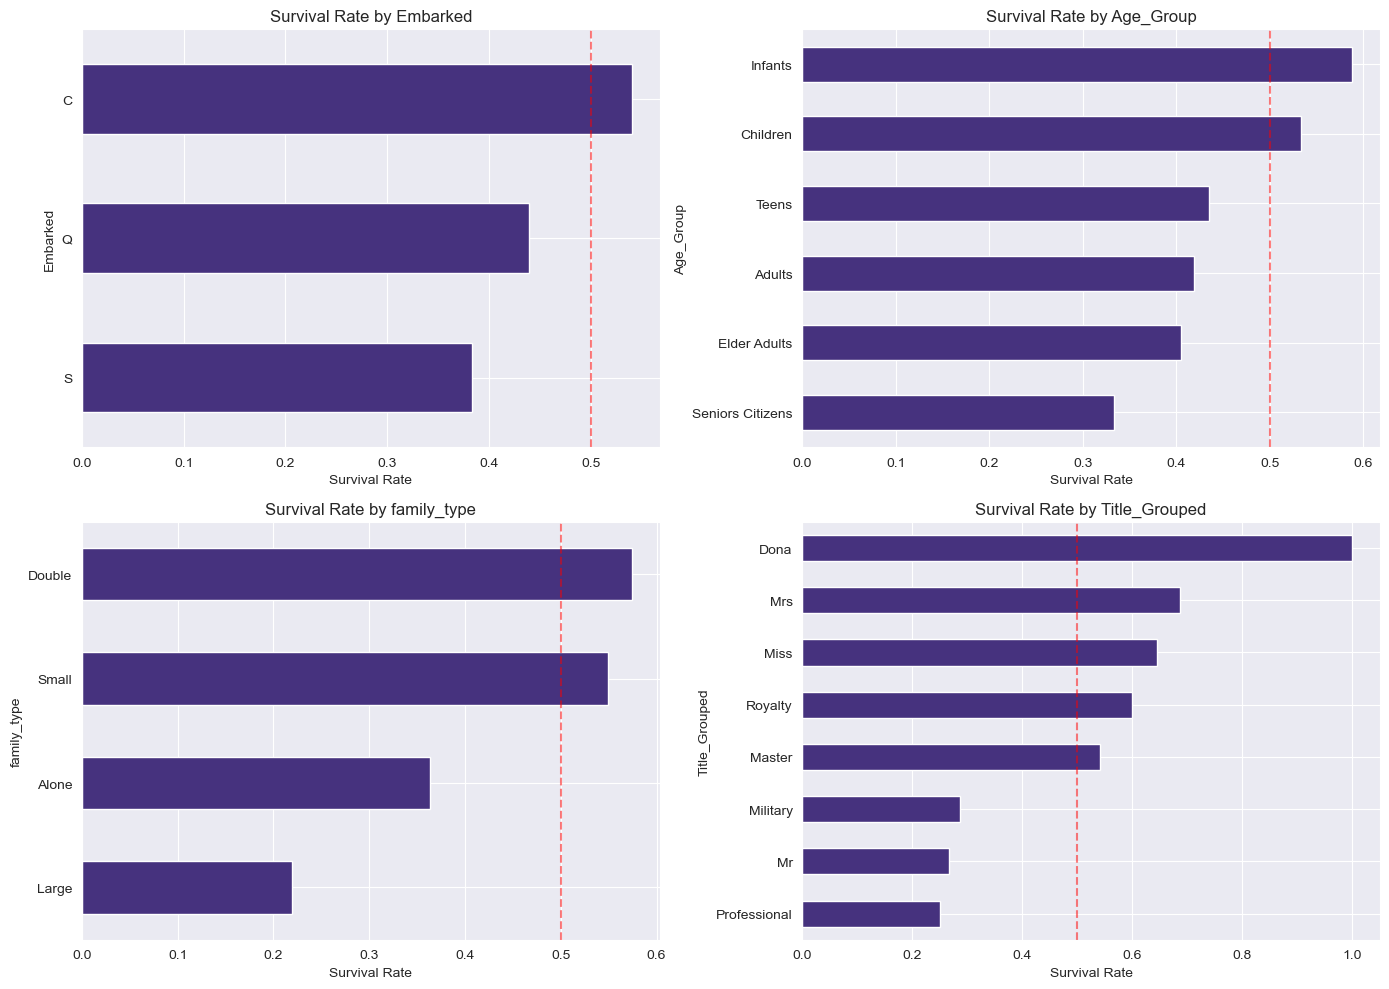

In [23]:
cats = ['Embarked', 'Age_Group', 'family_type', 'Title_Grouped']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), cats):
    rates = df.groupby(col)['Survived'].mean().sort_values()
    rates.plot(kind='barh', ax=ax)
    print(rates*100)
    print("-"*35)
    ax.set_title(f'Survival Rate by {col}')
    ax.set_xlabel('Survival Rate')
    ax.axvline(0.5, linestyle='--', color='red', alpha=0.5)
plt.tight_layout()
plt.show()

Sex        female       male
Pclass                      
1       80.555556  39.664804
2       82.075472  31.578947
3       49.537037  23.529412


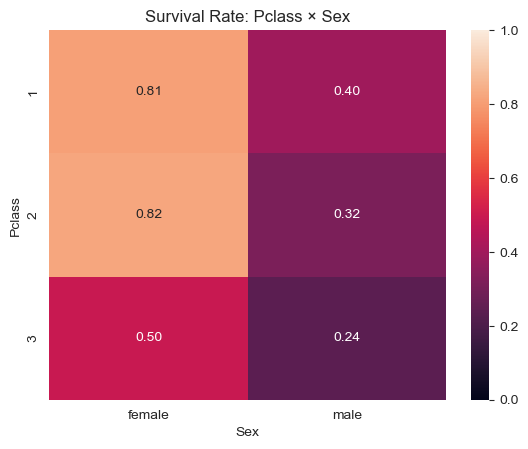

In [24]:
pivot = df.pivot_table(values='Survived', index='Pclass', columns='Sex', aggfunc='mean')
print(pivot*100)
sns.heatmap(pivot, annot=True, fmt='.2f', vmin=0, vmax=1)
plt.title('Survival Rate: Pclass × Sex')
plt.show()

### Observation:- 
- In 1st Class Females were 81% saved and males 40%.
- In 2nd Class Females were 80% Saved and Males 32%.
- In 3rd Class Females were 51% saved and Males 23%

**CAT vs NUM**

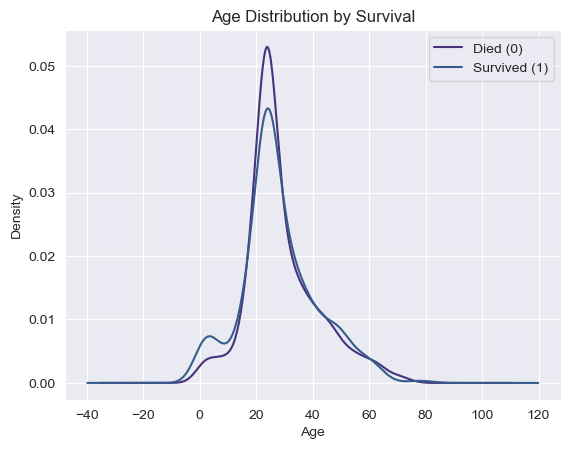

In [25]:
# Survival by Age.

df.groupby('Survived')['Age'].plot(kind='kde',legend=True)
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.legend(['Died (0)', 'Survived (1)'])
plt.show()

**Observation:-**
- The age between 15 to 50 are the passengers those who survived the most in this incident.

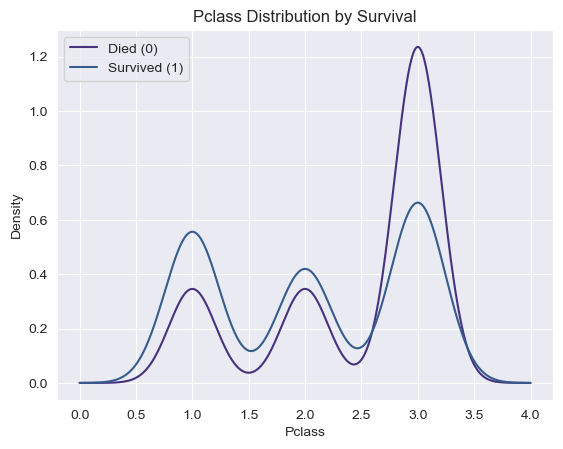

In [26]:
# Survival by Pclass

df.groupby('Survived')['Pclass'].plot(kind='kde', legend=True)
plt.title('Pclass Distribution by Survival')
plt.xlabel('Pclass')
plt.legend(['Died (0)', 'Survived (1)'])
plt.show()

**Observation:-**
- First class people were saved the most and 3rd class were suffered the most.

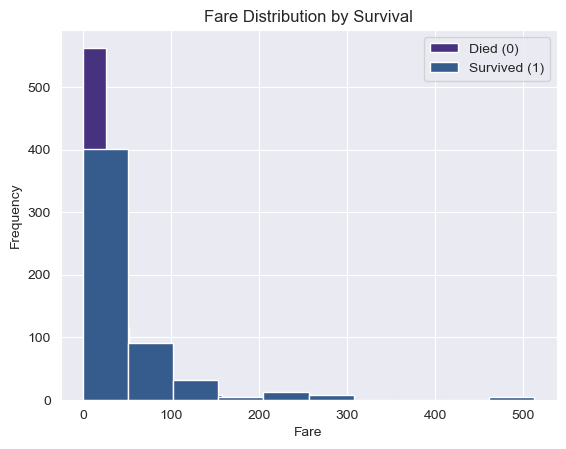

In [27]:
# Survived by Fare

df.groupby('Survived')['Fare'].plot(kind='hist', legend=True)
plt.title('Fare Distribution by Survival')
plt.xlabel('Fare')
plt.legend(['Died (0)', 'Survived (1)'])
plt.show()

**Observation:-**
- The passengers who had not paid a single dollar has suffered most with their lifes.

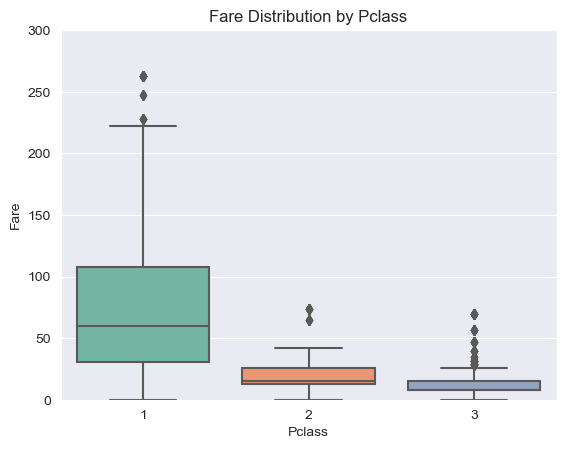

In [53]:
# Fare by Pcalss

sns.boxplot(data=df, x='Pclass', y='Fare', palette='Set2')
plt.title('Fare Distribution by Pclass')
plt.ylim(0, 300)  # cap outliers
plt.show()

**Observation**
- From the above chart we can state that the Pclass has having the most fare according to the remain 2 classes.

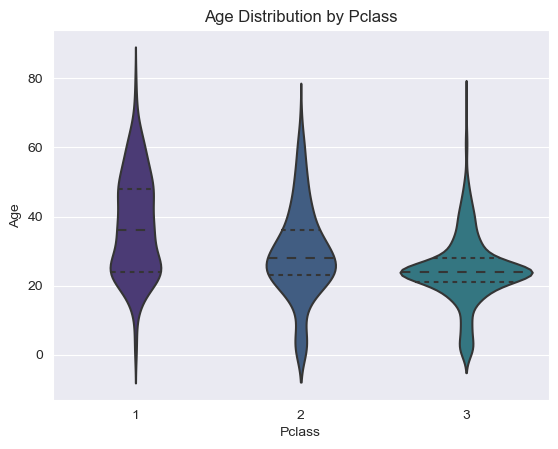

In [29]:
# Age and Pclass

sns.violinplot(data=df, x='Pclass', y='Age', inner='quartile')
plt.title('Age Distribution by Pclass')
plt.show()

### Observation:- 

- We observed that in 1st Class the average passengers were saved was of age 40,
- In 2nd class it was around 35.
- In 3rd class it was approx 23-25.

Sex
female    46.198097
male      26.163072
Name: Fare, dtype: float64


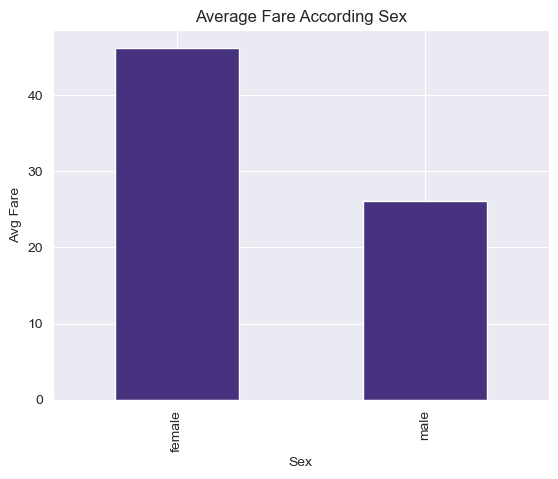

In [30]:
# Average fare of the gender.

av_fare = df.groupby("Sex")['Fare'].mean()
av_fare.plot(kind='bar')
plt.title("Average Fare According Sex")
plt.ylabel("Avg Fare")
print(av_fare)

### Observation:- 

- We can see the average fare for womens was also high(46.19) comparing to males(26.15)

Sex
female    62.500000
male      50.847458
Name: Survived, dtype: float64


<AxesSubplot:xlabel='Sex'>

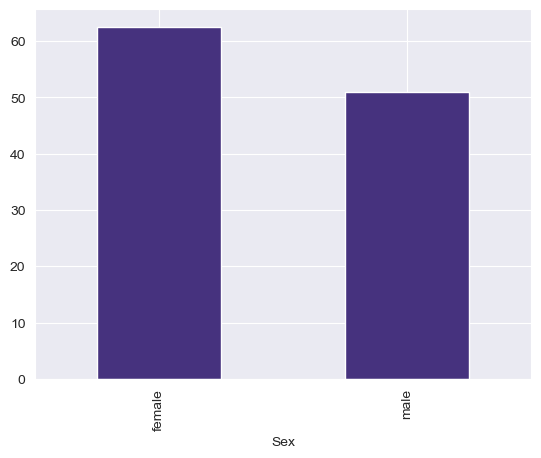

In [31]:
# Children survived in this accident.

children = df[df['Age']<16]
child_grp = children.groupby("Sex")['Survived'].mean()*100
print(child_grp)
child_grp.plot(kind='bar')

### Observations:- 

- We can see that in Children the Female Children were saved the most around(65.11%) and the Male children were saved the least(52.50%).

### NUM vs NUM

In [32]:
# SibSp Survival rate

df.groupby('SibSp').agg(
    Total_Passengers = ('Survived', 'count'),
    Total_Survived   = ('Survived', 'sum'),
    Survival_Pct     = ('Survived', lambda x: round(x.mean()*100, 1))
).sort_values(by= "Survival_Pct",ascending=False)

,Total_Passengers,Total_Survived,Survival_Pct
SibSp,,,
1,319,167.0,52.4
2,42,19.0,45.2
0,891,355.0,39.8
3,20,5.0,25.0
4,22,4.0,18.2
8,9,1.0,11.1
5,6,0.0,0.0


Text(0.5, 1.0, 'Survival Rate For SibSp')

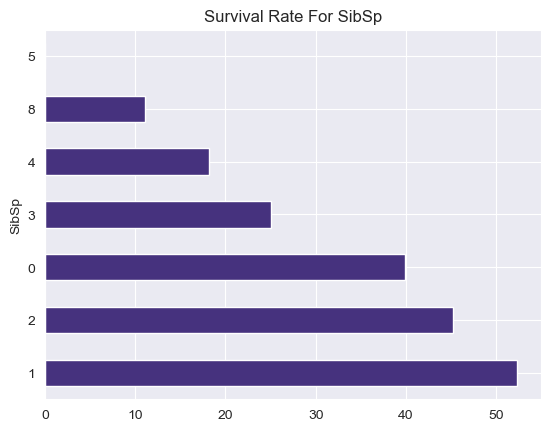

In [33]:
# Survival Rate for Siblings and spouses.

grp = df.groupby("SibSp")['Survived'].mean().sort_values(ascending = False)*100
grp.plot(kind='barh')
plt.title("Survival Rate For SibSp")

### Observation:-
- According to the data we can clearly see the passengers those who have someone with them have the more possibility of the survival comparing to the family or large group.

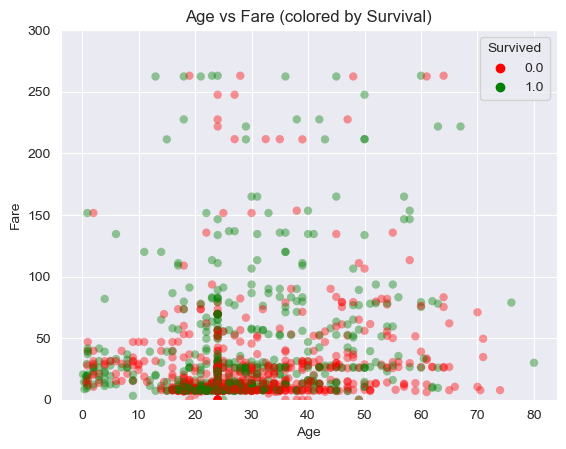

In [34]:
# Multivariate Age vs Fare by survival.

sns.scatterplot(data=df, x='Age', y='Fare',hue='Survived',
                palette={0: 'red', 1: 'green'}, alpha=0.4, edgecolor='none' )
plt.title('Age vs Fare (colored by Survival)')
plt.ylim(0, 300)
plt.show()

### Observations:- 

- We can clearly observe that the people those who had purchased the higher price ticket were survived the most. Also the more passenger died those who purchased the least price tickets.

Parch
9    100.000000
1     53.529412
2     50.442478
6     50.000000
0     39.421158
3     37.500000
4     16.666667
5     16.666667
Name: Survived, dtype: float64


Text(0.5, 1.0, 'Survival with Parent and Child')

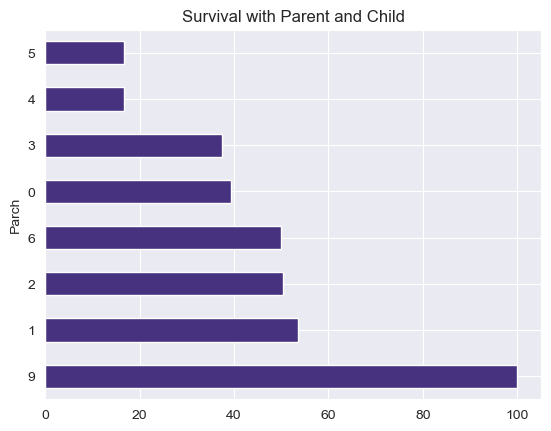

In [35]:
# Average survival of Parch

grp = df.groupby('Parch')['Survived'].mean().sort_values(ascending = False)*100
grp.plot(kind='barh')
print(grp)
plt.title("Survival with Parent and Child")

In [36]:
df.groupby('Parch').agg(
    Total_Passengers = ('Survived', 'count'),
    Total_Survived   = ('Survived', 'sum'),
    Survival_Pct     = ('Survived', lambda x: round(x.mean()*100, 1))
).sort_values(by='Survival_Pct',ascending=False)

,Total_Passengers,Total_Survived,Survival_Pct
Parch,,,
9,2,2.0,100.0
1,170,91.0,53.5
2,113,57.0,50.4
6,2,1.0,50.0
0,1002,395.0,39.4
3,8,3.0,37.5
4,6,1.0,16.7
5,6,1.0,16.7


### Observation:- 
- From the above observation we can state that the small family i.e. 1 parent 2 child or 2 child (consiting of total 3 members) has survived the most.

Embarked and Survived count:- Embarked
C    270
Q    123
S    916
Name: Survived, dtype: int64
---------------------------------------------
Embarked and Survived Average:- Embarked
C    54.074074
Q    43.902439
S    38.318777
Name: Survived, dtype: float64


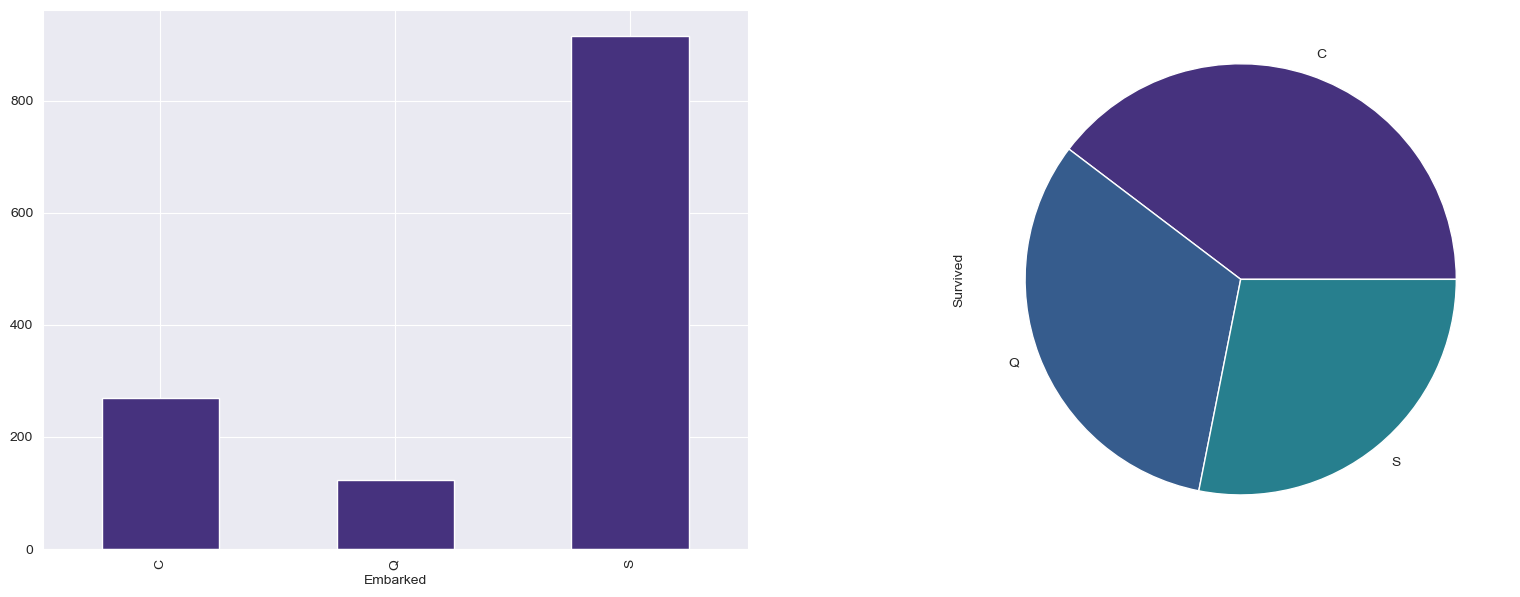

In [37]:
# Analysis on Embarked
fig,ax = plt.subplots(1,2,figsize = (20,7))

Emb_sur_cnt = df.groupby("Embarked")['Survived'].count()
Emb_sur = df.groupby("Embarked")['Survived'].mean()*100

Emb_sur_cnt.plot(kind='bar',ax=ax[0])
Emb_sur.plot(kind="pie",ax=ax[1])

print(f"Embarked and Survived count:- {Emb_sur_cnt}")
print("-"*45)
print(f"Embarked and Survived Average:- {Emb_sur}")

**Observations on Embarked:-**
- We noticed that the most numbers of passengers were survived on C(Cherbourg) i.e. 55.35% but having only 168 passengers.
- In Q(Queenstown) 38.96 % passengers survived having only 77 Passengers on board.
- In S(Southampton) 33.69% Passengers survived having total of 644 Passengers.

Pclass and Survived count:- Pclass
1    323
2    277
3    709
Name: Survived, dtype: int64
---------------------------------------------
Pclass and Survived Average:- Pclass
1    57.894737
2    50.902527
3    31.452750
Name: Survived, dtype: float64


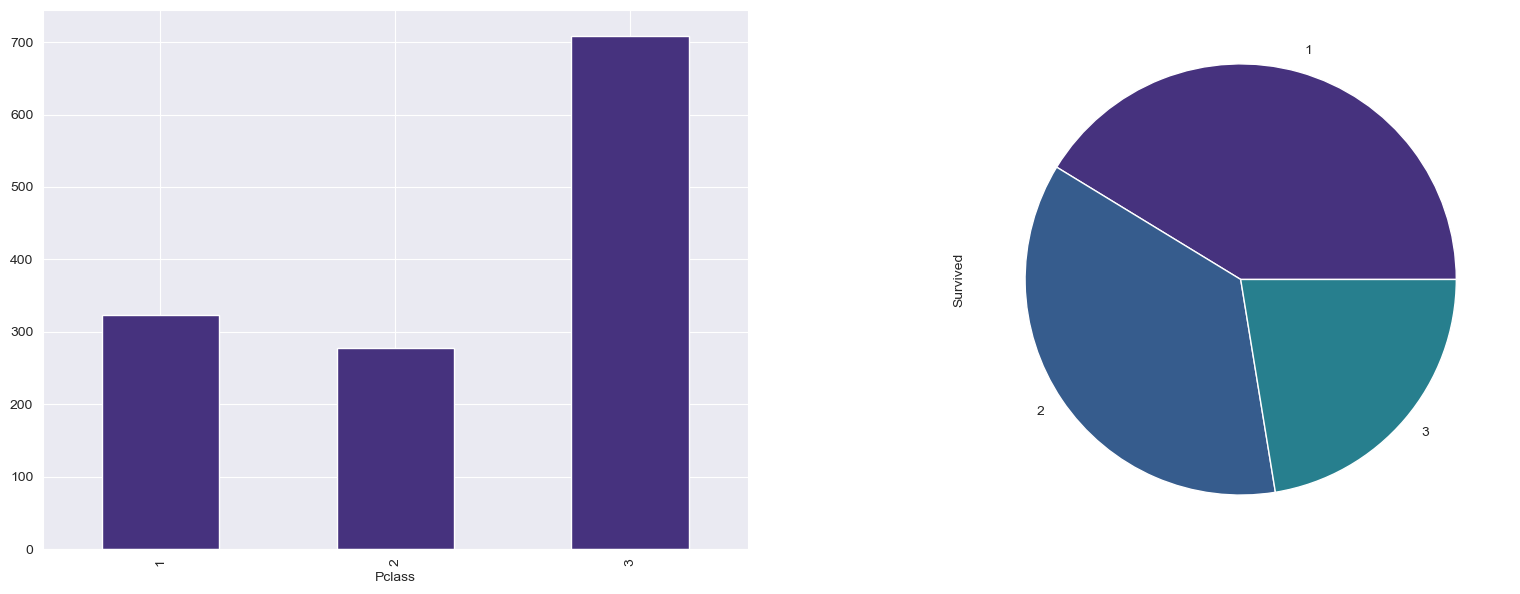

In [38]:
# Analysis of Pclass and Their Survival Rate in %.
fig,ax = plt.subplots(1,2,figsize = (20,7))

class_sur = df.groupby("Pclass")['Survived'].mean()*100
class_sur_cnt = df.groupby("Pclass")['Survived'].count()

class_sur_cnt.plot(kind='bar',ax=ax[0])
class_sur.plot(kind="pie",ax=ax[1])

print(f"Pclass and Survived count:- {class_sur_cnt}")
print("-"*45)
print(f"Pclass and Survived Average:- {class_sur}")

**Observations from above charts:-**
- According to the data around **216** i.e. **62.96 %** of average passengers has survived in Pclass 1. In Pclass 2 **184** i.e. **47.28%** and in Pclass 3 **419** i.e. **24.23%** 

# Comparing all at one place.

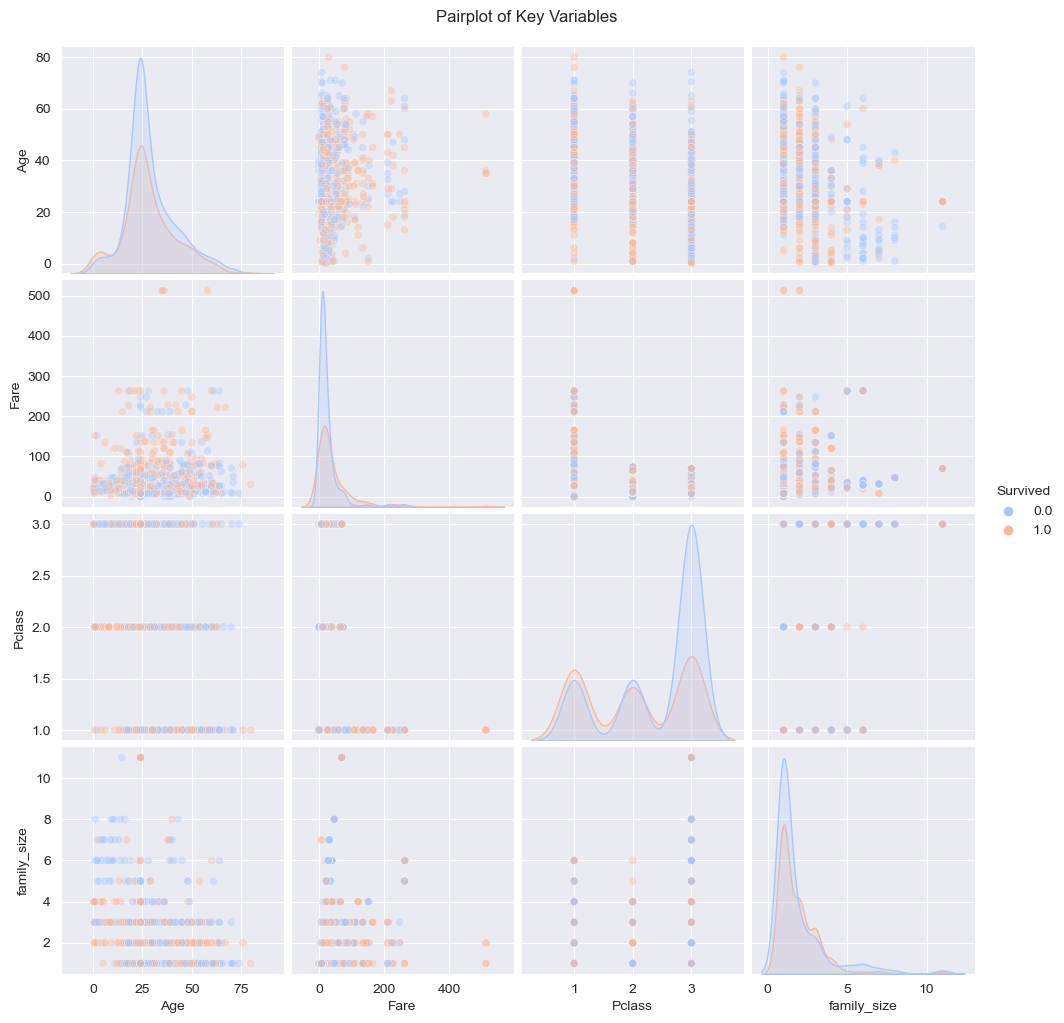

In [39]:
# We have compared every bivariate analysis at one place.

sns.pairplot(df[['Survived', 'Age', 'Fare', 'Pclass', 'family_size']].dropna(),
             hue='Survived', plot_kws={'alpha': 0.4}, palette='coolwarm',
             diag_kind='kde')
plt.suptitle('Pairplot of Key Variables', y=1.02)
plt.show()

**----------------------------------------------------------------**

# Multi-Variate Analysis.

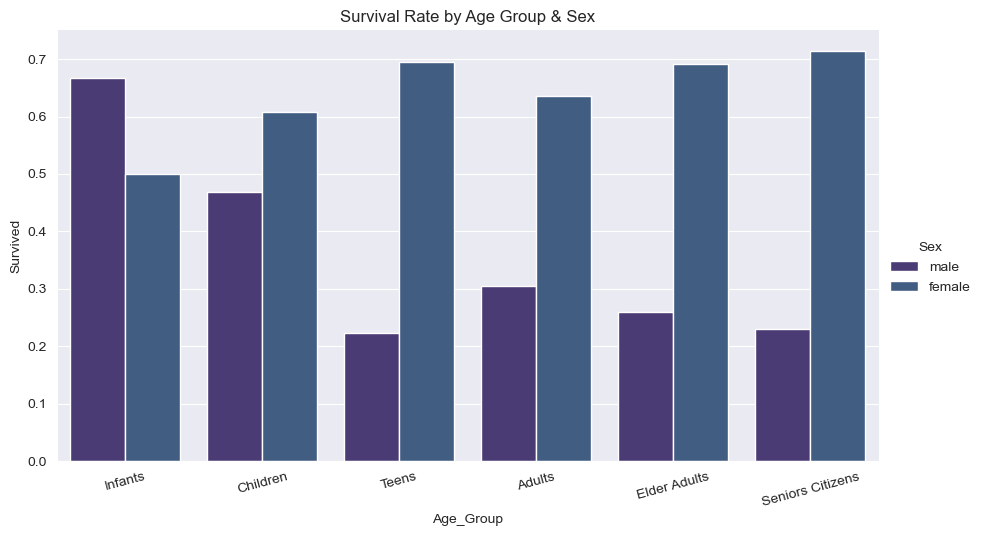

In [40]:
# Survival rate of AgeGroup according to Sex.

sns.catplot(data=df, x='Age_Group', y='Survived', hue='Sex',
            kind='bar', height=5, aspect=1.8, ci=False,
            order=['Infants','Children','Teens','Adults','Elder Adults','Seniors Citizens'])
plt.title('Survival Rate by Age Group & Sex')
plt.xticks(rotation=15)
plt.show()

### Observation:- 
- Only Infants and Children are categories where the males and females are saved the most

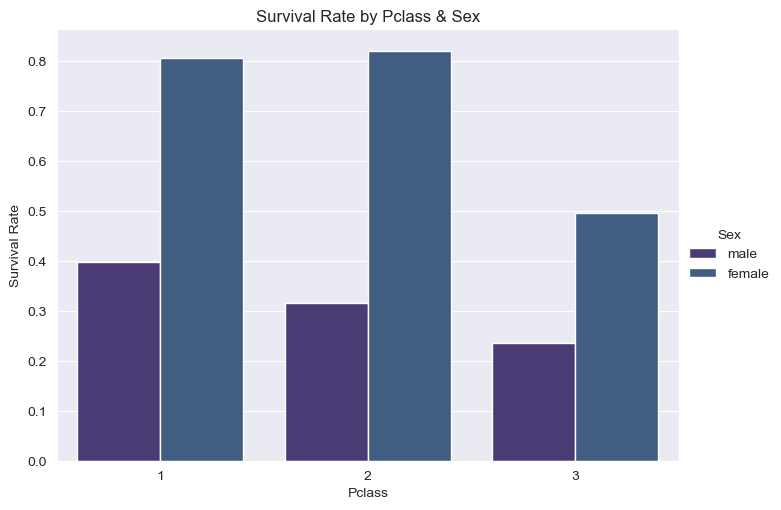

In [41]:
# Survival Rate By Sex and Pclass

sns.catplot(data=df, x='Pclass', y='Survived', hue='Sex', kind='bar', height=5, aspect=1.4, ci=False)
plt.title('Survival Rate by Pclass & Sex')
plt.ylabel('Survival Rate')
plt.show()

### Observation:- 
- When we analysed the Survival and Pclass along with Sex we get to know that in all the 3 classes Females were saved like more than 50%.

Text(0.5, 1.0, 'Survival of Sex and Embarked.')

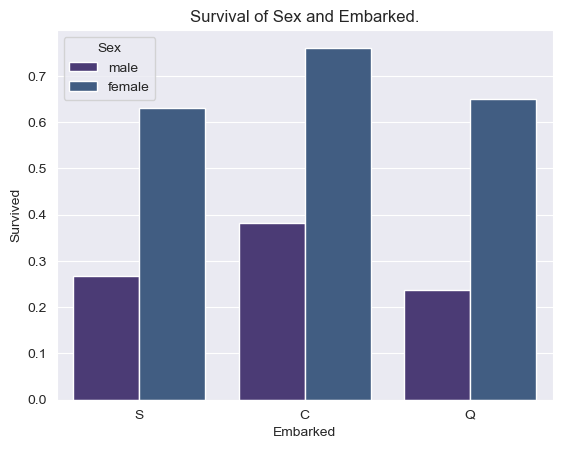

In [42]:
sns.barplot(data=df, x='Embarked',y='Survived',hue='Sex',ci=False)
plt.title("Survival of Sex and Embarked.")

### Observation:- 
- Also in Embarked mostly Females were saved.

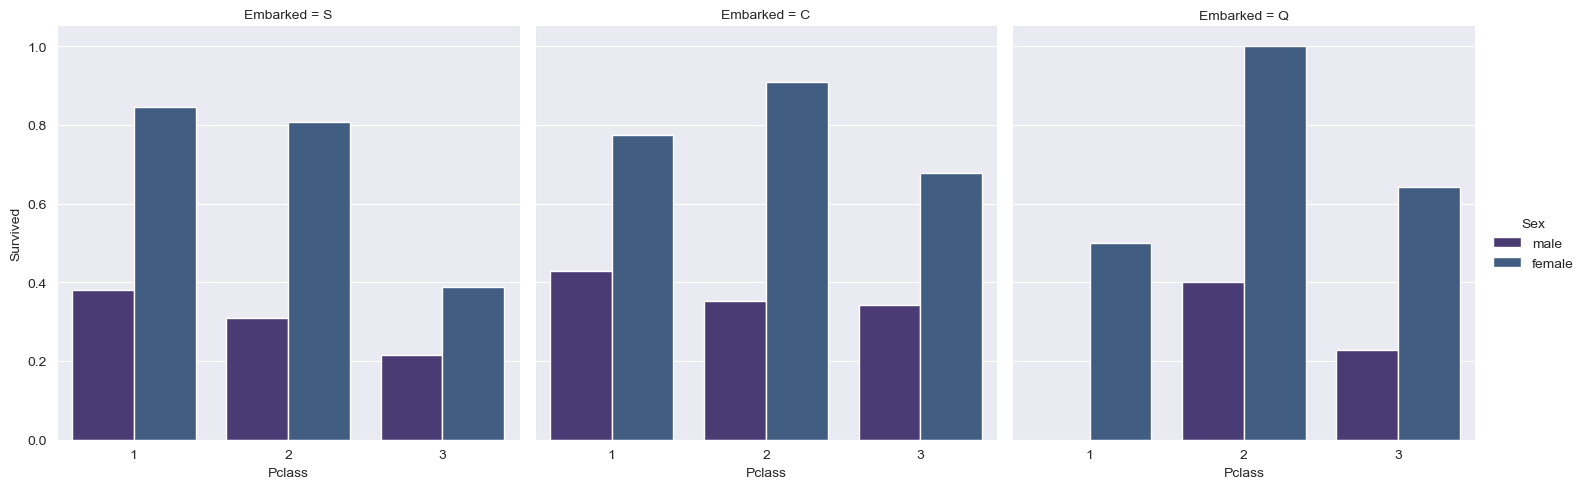

In [43]:
sns.catplot(data=df, x='Pclass',y='Survived', hue='Sex',col='Embarked',
            kind='bar',ci=False )


In [44]:
# Looking for difference after filling the values.

for col in ['Age','Embarked','Fare','Cabin']:
    print("\n", col)

    print("Before")
    print(original_df[col].value_counts(dropna=False, normalize=True)*100)

    print("\nAfter")
    print(df[col].value_counts(dropna=False, normalize=True)*100)


 Age
Before
NaN     20.091673
24.0     3.590527
22.0     3.284950
21.0     3.132162
30.0     3.055768
          ...    
23.5     0.076394
20.5     0.076394
55.5     0.076394
66.0     0.076394
38.5     0.076394
Name: Age, Length: 99, dtype: float64

After
24.0    23.682200
22.0     3.284950
21.0     3.132162
30.0     3.055768
18.0     2.979374
          ...    
23.5     0.076394
70.5     0.076394
55.5     0.076394
20.5     0.076394
38.5     0.076394
Name: Age, Length: 98, dtype: float64

 Embarked
Before
S      69.824293
C      20.626432
Q       9.396486
NaN     0.152788
Name: Embarked, dtype: float64

After
S    69.977082
C    20.626432
Q     9.396486
Name: Embarked, dtype: float64

 Fare
Before
8.0500     4.583652
13.0000    4.507257
7.7500     4.201681
26.0000    3.819710
7.8958     3.743316
             ...   
26.2833    0.076394
14.0000    0.076394
15.0000    0.076394
6.2375     0.076394
7.7208     0.076394
Name: Fare, Length: 282, dtype: float64

After
8.0500     4.583652
13.0000

# Some common Questions about this Dataset Analysis

#### 1. What was the objective of the Titanic project?

- The objective was to identify the factors that influenced passenger survival during the Titanic disaster and understand how demographic, ticket, and family-related characteristics affected survival outcomes.


#### 2. Which Features were most related to survival?
- Based on my analysis the top factors:
    - Sex
    - Pclass
    - Fare
    - Embarked
    - Family Size
- Gender and passenger class showed the strongest relationship with survival. Fare and embarkation location also had significant influence, while age had a comparatively weaker impact.


#### 3. Did gender impact survival?
- Yes. Gender was one of the strongest predictors of survival. Female passengers had significantly higher survival rates compared to male passengers across all passenger classes.

#### 4. Did passenger class impact survival?
- Yes. First-class passengers had the highest survival rate, followed by second-class passengers, while third-class passengers had the lowest survival rate.
- Pclass 1 → 62.96%
- Pclass 2 → 47.28%
- Pclass 3 → 24.23%

#### 5. What was the survival rate?
- Approximately 42.9% of passengers survived while 57.1% did not survive.

#### 6. What insights did you find from Age?
- Most passengers belonged to the young-adult age group. Children and infants showed relatively better survival rates, supporting the "women and children first" evacuation pattern. Age alone was not as strong a predictor as gender or passenger class.

#### 7. What challenges did you face while cleaning?
- The primary challenge was handling missing values, particularly in Age and Cabin. I had to evaluate different imputation techniques such as mean, median, mode, and random filling while ensuring that the underlying data distribution was not distorted.

#### 8. Why did you choose those visualizations?
- I selected visualizations based on the type of variables being analyzed:
    - Histograms and KDE plots for numerical distributions
    - Boxplots for outlier detection
    - Countplots and bar charts for categorical comparisons
    - Heatmaps for relationship analysis
    - Scatterplots for multivariate exploration
    - Pairplots to understand interactions among multiple numerical features simultaneously
    
#### 9. What business recommendations would you provide?
- Based on the analysis:
    - Emergency evacuation procedures should prioritize vulnerable groups such as children and elderly passengers.
    - Equal access to lifeboats should be ensured across all passenger classes.
    - Passenger safety training should be standardized regardless of ticket class.
    - Capacity planning should account for family groups because passengers traveling with small families showed higher survival rates.